## AI 모델 개발 15회차 1차 팀프로젝트 - NASA Turbofan Jet Engine Data Set 터보엔진 유지보전 문제_FD002

[데이터셋 개요]
이 데이터셋은 NASA의 C-MAPSS(Commercial Modular Aero-Propulsion System Simulation)
시뮬레이터를 사용하여 생성된 터보팬 엔진의 열화(Degradation) 데이터입니다.

데이터는 여러 개의 다변량 시계열(Multivariate Time Series)로 구성되어 있습니다.
데이터셋은 학습(Training) 세트와 테스트(Test) 세트로 나뉩니다.
각 시계열 데이터는 서로 다른 엔진(Unit)에서 얻은 데이터이며, 동일한 유형의 엔진들로 간주할 수 있습니다.

[실험 시나리오]
1. 초기 상태: 각 엔진은 정상 상태에서 작동을 시작합니다.
   - 단, 사용자에게는 알려지지 않은 수준의 초기 마모(Initial Wear)와 제조 공차(Variation)가 존재합니다.
     (이는 결함이 아닌 정상적인 범주입니다.)
2. 고장 진행: 어느 시점부터 결함(Fault)이 발생하여 시간이 지날수록 상태가 악화됩니다.
3. 데이터 범위:
   - 학습 세트 (Train): 결함 발생부터 시스템 고장(Failure) 시점까지의 모든 데이터가 포함됩니다.
   - 테스트 세트 (Test): 고장 발생 전 임의의 시점에서 데이터 기록이 중단됩니다.

[목표 (Objective)]
테스트 세트에 포함된 각 엔진의 **잔여 유효 수명(RUL: Remaining Useful Life)**을 예측하는 것입니다.
즉, 테스트 데이터가 끊긴 시점으로부터 엔진이 고장 날 때까지 몇 사이클(Cycle)이 더 남았는지 맞히는 것이 목표입니다.

> FD002 (Train: train_FD002.txt / Test: test_FD002.txt / RUL: RUL_FD002.txt)
   - 학습 엔진 수: 260개
   - 테스트 엔진 수: 259개
   - 운전 조건 (Conditions): 6가지 (다양한 고도, 속도, 부하 조건)
   - 고장 모드 (Fault Modes): 1가지 (HPC 열화)


> 여러 셀에서 사용되는 함수는 먼저 정의하고 시작한다. 코드 오류 방지

## 1. 라이브러리 및 데이터 로드

In [94]:
# 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. 데이터 불러오기

In [95]:
# 데이터 가져오기
import os
HOME = os.getcwd()
zipPath = os.path.join(HOME, "nasa-cmaps.zip")
targetPath = os.path.join(HOME, 'data')

from zipfile import ZipFile

with ZipFile(zipPath, 'r') as zip_ref:
    zip_ref.extractall(targetPath)


In [96]:
parent_path = "C:/Users/alstj/OneDrive/문서/GitHub/EST_15th_NASA/전민서/CMaps"

#FD_ID = "FD001" # Conditions: ONE (Sea Level), Fault Modes: ONE (HPC Degradation)
FD_ID = "FD002" # Conditions: SIX, Fault Modes: ONE (HPC Degradation)
#FD_ID = "FD003" # Conditions: ONE (Sea Level), Fault Modes: TWO (HPC Degradation, Fan Degradation)
#FD_ID = "FD004" # Conditions: SIX , Fault Modes: TWO (HPC Degradation, Fan Degradation)

train_path = os.path.join(parent_path, f"train_{FD_ID}.txt")
test_path  = os.path.join(parent_path, f"test_{FD_ID}.txt")
rul_path   = os.path.join(parent_path, f"RUL_{FD_ID}.txt")

print(f"Train path: {train_path}")

col_names = [
    "unit_number", "time_in_cycles",
    "op_setting_1", "op_setting_2", "op_setting_3"
] + [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=col_names)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None, names=col_names)
rul_df = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["RUL"])


Train path: C:/Users/alstj/OneDrive/문서/GitHub/EST_15th_NASA/전민서/CMaps\train_FD002.txt


## 3. Feature Engineering

In [97]:
rename_dict = {
    "op_setting_1": "Alt[kft]", # Altitude
    "op_setting_2": "Mn[-]", # Mach number
    "op_setting_3": "TLA[deg]", # Thrust lever angle (detent?)
    "sensor_1": "T2[R]",  # Total temperature at fan inlet 
    "sensor_2": "T24[R]", # Total temperature at LPC outlet
    "sensor_3": "T30[R]", # Total temperature at HPC outlet
    "sensor_4": "T50[R]", # Total temperature at LPT outlet
    "sensor_5": "P2[psi]", # Pressure at fan inlet
    "sensor_6": "P15[psi]", # Total pressure in bypass-duct
    "sensor_7": "P30[psi]", # Total pressure at HPC outlet
    "sensor_8": "Nf[rpm]", # Physical fan speed
    "sensor_9": "Nc[rpm]", # Physical core speed
    "sensor_10": "epr[-]", # Engine pressure ratio (P50/P2)
    "sensor_11": "phi[pph/psi]", # Ratio of fuel flow to Ps30, (not pps/psi, but pph/psi)
    "sensor_12": "Ps30[psi]", # Static pressure at HPC outlet
    "sensor_13": "NRf[rpm]", # Corrected fan speed
    "sensor_14": "NRc[rpm]", # Corrected core speed
    "sensor_15": "BPR[-]", # Bypass Ratio
    "sensor_16": "farB[-]", # Burner fuel-air ratio
    "sensor_17": "htBleed[]",# Bleed Enthalpy
    "sensor_18": "Nf_dmd[rpm]", # Demanded fan speed
    "sensor_19": "PCNfR_dmd[Pct]", # Demanded corrected fan speed
    "sensor_20": "W31[lbm/s]", # HPT coolant bleed
    "sensor_21": "W32[lbm/s]", # LPT coolant bleed
}


train_df = train_df.rename(columns=rename_dict)
test_df  = test_df.rename(columns=rename_dict)

def clean_round(series, ndigits=1, eps=1e-6):
    """Round values and force -0.0 to 0.0"""
    rounded = series.round(ndigits)
    rounded[rounded.abs() < eps] = 0
    return rounded

train_df['condition'] = (
    clean_round(train_df["Alt[kft]"], 0).astype(str) + '_' +
    clean_round(train_df["Mn[-]"], 1).astype(str) + '_' +
    clean_round(train_df["TLA[deg]"], 0).astype(str)
)

train_df.head()

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,NRf[rpm],NRc[rpm],BPR[-],farB[-],htBleed[],Nf_dmd[rpm],PCNfR_dmd[Pct],W31[lbm/s],W32[lbm/s],condition
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071,35.0_0.8_100.0
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665,42.0_0.8_100.0
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723,25.0_0.6_60.0
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701,42.0_0.8_100.0
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286,25.0_0.6_60.0


In [98]:
train_df["P50[psi]"] = train_df["epr[-]"]*train_df["P2[psi]"]

train_df["Fan.PR[-]"] = train_df["P15[psi]"]/train_df["P2[psi]"]
train_df["LPC.TR[-]"] = train_df["T24[R]"]/train_df["T2[R]"] # Fan core + LPC
train_df["HPC.TR[-]"] = train_df["T30[R]"]/train_df["T24[R]"]

train_df["OPR[-]"] = train_df["P30[psi]"]/train_df["P2[psi]"]

train_df["Wf[pph]"] = train_df["phi[pph/psi]"]*train_df["Ps30[psi]"]
train_df["Wa36[lbm/s]"] = train_df["Wf[pph]"]/3600.0 / train_df["farB[-]"]
train_df["W24[lbm/s]"] = train_df["Wa36[lbm/s]"] + train_df["W31[lbm/s]"] + train_df["W32[lbm/s]"] # core. htBleed ? 
train_df["W15[lbm/s]"] = train_df["W24[lbm/s]"]*train_df["BPR[-]"] # bypass
train_df["W2[lbm/s]"] = train_df["W15[lbm/s]"] + train_df["W24[lbm/s]"] # overall

train_df["WfP3C[pph/psi]"] = train_df["phi[pph/psi]"]/np.sqrt(train_df["T2[R]"]/518.67)

train_df.head()


,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,Fan.PR[-],LPC.TR[-],HPC.TR[-],OPR[-],Wf[pph],Wa36[lbm/s],W24[lbm/s],W15[lbm/s],W2[lbm/s],WfP3C[pph/psi]
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,1.459854,1.235582,2.446535,35.518248,7692.1812,106.835850,130.372950,1218.478628,1348.851578,45.140436
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,1.460358,1.235730,2.460847,35.424552,5503.7240,76.440611,93.117111,873.196398,966.313509,45.559401
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,1.279433,1.161651,2.338985,24.923404,6025.2318,83.683775,106.436075,1159.525245,1265.961320,38.852470
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,1.460358,1.234854,2.464068,35.411765,5485.0112,76.180711,93.240811,872.062658,965.303469,45.300296
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,1.280851,1.161132,2.341799,24.829787,6061.3959,84.186054,106.844654,1164.211405,1271.056059,39.064257


### 컬럼 설명 (Data Dictionary)

| 컬럼명 | 설명 | 타입 |
|---|---|---|
| **unit_number** | 엔진 고유 식별자 (Unit Number) | int64 |
| **time_in_cycles** | 운전 사이클 (Time in Cycles) | int64 |
| **Alt[kft]** | 고도 (Altitude) | float64 |
| **Mn[-]** | 마하 수 (Mach Number) | float64 |
| **TLA[deg]** | 스로틀 레버 각도 (Thrust Lever Angle) | float64 |
| **T2[R]** | 팬 입구 전온도 (Total temperature at fan inlet) | float64 |
| **T24[R]** | LPC 출구 전온도 (Total temperature at LPC outlet) | float64 |
| **T30[R]** | HPC 출구 전온도 (Total temperature at HPC outlet) | float64 |
| **T50[R]** | LPT 출구 전온도 (Total temperature at LPT outlet) | float64 |
| **P2[psi]** | 팬 입구 압력 (Pressure at fan inlet) | float64 |
| **P15[psi]** | 바이패스 덕트 전압력 (Total pressure in bypass-duct) | float64 |
| **P30[psi]** | HPC 출구 전압력 (Total pressure at HPC outlet) | float64 |
| **Nf[rpm]** | 물리적 팬 속도 (Physical fan speed) | float64 |
| **Nc[rpm]** | 물리적 코어 속도 (Physical core speed) | float64 |
| **epr[-]** | 엔진 압력비 (Engine pressure ratio) | float64 |
| **phi[pph/psi]** | 연료 유량 대 Ps30 비율 (Ratio of fuel flow to Ps30) | float64 |
| **Ps30[psi]** | HPC 출구 정압 (Static pressure at HPC outlet) | float64 |
| **NRf[rpm]** | 보정된 팬 속도 (Corrected fan speed) | float64 |
| **NRc[rpm]** | 보정된 코어 속도 (Corrected core speed) | float64 |
| **BPR[-]** | 바이패스 비 (Bypass Ratio) | float64 |
| **farB[-]** | 연소기 연료-공기 비 (Burner fuel-air ratio) | float64 |
| **htBleed[]** | 블리드 엔탈피 (Bleed Enthalpy) | int64 |
| **Nf_dmd[rpm]** | 요구 팬 속도 (Demanded fan speed) | int64 |
| **PCNfR_dmd[Pct]** | 요구 보정 팬 속도 (Demanded corrected fan speed) | float64 |
| **W31[lbm/s]** | HPT 냉각 블리드 (HPT coolant bleed) | float64 |
| **W32[lbm/s]** | LPT 냉각 블리드 (LPT coolant bleed) | float64 |
| **condition** | 운전 조건 문자열 (Operational Condition String) | object |
| **P50[psi]** | LPT 출구 전압력 (Total pressure at LPT outlet) | float64 |
| **Fan.PR[-]** | 팬 압력비 (Fan pressure ratio) | float64 |
| **LPC.TR[-]** | LPC 전온도비 (LPC total temperature ratio) | float64 |
| **HPC.TR[-]** | HPC 전온도비 (HPC total temperature ratio) | float64 |
| **OPR[-]** | 전체 압력비 (Overall pressure ratio) | float64 |
| **Wf[pph]** | 연료 유량 (Fuel flow) | float64 |
| **Wa36[lbm/s]** | 코어 공기 유량 (Core airflow) | float64 |
| **W24[lbm/s]** | LPC 공기 유량 (LPC airflow) | float64 |
| **W15[lbm/s]** | 바이패스 공기 유량 (Bypass airflow) | float64 |
| **W2[lbm/s]** | 팬 유입 공기 유량 (Fan inlet airflow) | float64 |
| **WfP3C[pph/psi]** | P3 압력 대비 연료 유량 (Fuel flow to P3 pressure ratio) | float64 |
| **RUL** | 엔진의 남은 수명 (Remaining Useful Life) | int64 |

In [99]:
import pandas as pd
import numpy as np

def apply_full_preprocessing(train, test):
    train_proc = train.copy()
    test_proc = test.copy()

    # [1] 물리량 및 특성 생성 (Train/Test 공통 적용)
    for df in [train_proc, test_proc]:
        # 운전 조건 문자열 생성
        df['condition'] = (
            df["Alt[kft]"].round(0).astype(int).astype(str) + '_' +
            df["Mn[-]"].round(1).astype(str) + '_' +
            df["TLA[deg]"].round(0).astype(int).astype(str)
        )
        
        # 물리 지표 계산
        df["P50[psi]"] = df["epr[-]"] * df["P2[psi]"]
        df["Fan.PR[-]"] = df["P15[psi]"] / df["P2[psi]"]
        df["LPC.TR[-]"] = df["T24[R]"] / df["T2[R]"]
        df["HPC.TR[-]"] = df["T30[R]"] / df["T24[R]"]
        df["OPR[-]"] = df["P30[psi]"] / df["P2[psi]"]
        df["Wf[pph]"] = df["phi[pph/psi]"] * df["Ps30[psi]"]
        
        # 유량 및 효율 관련
        df["Wa36[lbm/s]"] = df["Wf[pph]"] / 3600.0 / (df["farB[-]"] + 1e-9)
        df["W24[lbm/s]"] = df["Wa36[lbm/s]"] + df["W31[lbm/s]"] + df["W32[lbm/s]"]
        df["W15[lbm/s]"] = df["W24[lbm/s]"] * df["BPR[-]"]
        df["W2[lbm/s]"] = df["W15[lbm/s]"] + df["W24[lbm/s]"]
        df["WfP3C[pph/psi]"] = df["phi[pph/psi]"] / np.sqrt(df["T2[R]"] / 518.67)

    # [2] Hard Clustering (Condition ID 부여)
    unique_conds = sorted(train_proc['condition'].unique())
    cond_map = {cond: i for i, cond in enumerate(unique_conds)}
    
    train_proc['condition_id'] = train_proc['condition'].map(cond_map)
    test_proc['condition_id'] = test_proc['condition'].map(cond_map)
    
    # [3] 조건별 정규화 및 Residual 생성
    exclude_cols = ['unit_number', 'time_in_cycles', 'condition', 'condition_id', 'RUL', 'max_cycle']
    sensor_cols = [c for c in train_proc.columns if train_proc[c].dtype in [np.float64, np.int64] and c not in exclude_cols]
    
    print(f"🚀 {len(sensor_cols)}개 피처에 대해 조건별 정규화 및 Residual 생성 중...")
    
    for col in sensor_cols:
        # Train의 통계치를 기준으로 Test도 정규화 (Data Leakage 방지)
        stats = train_proc.groupby('condition_id')[col].agg(['mean', 'std']).reset_index()
        
        # Train 적용
        train_proc = train_proc.merge(stats, on='condition_id', how='left')
        train_proc[f'{col}_res'] = (train_proc[col] - train_proc['mean']).abs()
        train_proc[col] = (train_proc[col] - train_proc['mean']) / (train_proc['std'] + 1e-9)
        train_proc.drop(['mean', 'std'], axis=1, inplace=True)
        
        # Test 적용
        test_proc = test_proc.merge(stats, on='condition_id', how='left')
        test_proc[f'{col}_res'] = (test_proc[col] - test_proc['mean']).abs()
        test_proc[col] = (test_proc[col] - test_proc['mean']) / (test_proc['std'] + 1e-9)
        test_proc.drop(['mean', 'std'], axis=1, inplace=True)

    # [4] 이상치 Clipping 및 Low-Variance Drop
    train_proc[sensor_cols] = train_proc[sensor_cols].clip(-3, 3)
    test_proc[sensor_cols] = test_proc[sensor_cols].clip(-3, 3)
    
    std_devs = train_proc[sensor_cols].std()
    low_var_cols = std_devs[std_devs < 0.01].index.tolist()
    
    train_proc.drop(columns=low_var_cols, inplace=True)
    test_proc.drop(columns=low_var_cols, inplace=True)
    
    print(f"✅ 완료: {len(low_var_cols)}개 저분산 컬럼 삭제 후 최종 {train_proc.shape[1]}개 컬럼 유지.")
    return train_proc, test_proc

# --- 실행부 ---
# rename_dict가 적용된 직후의 원본 train_df, test_df를 넣으시면 됩니다.
train_norm, test_norm = apply_full_preprocessing(train_df, test_df)

🚀 35개 피처에 대해 조건별 정규화 및 Residual 생성 중...
✅ 완료: 5개 저분산 컬럼 삭제 후 최종 69개 컬럼 유지.


In [100]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53759 entries, 0 to 53758
Data columns (total 38 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     53759 non-null  int64  
 1   time_in_cycles  53759 non-null  int64  
 2   Alt[kft]        53759 non-null  float64
 3   Mn[-]           53759 non-null  float64
 4   TLA[deg]        53759 non-null  float64
 5   T2[R]           53759 non-null  float64
 6   T24[R]          53759 non-null  float64
 7   T30[R]          53759 non-null  float64
 8   T50[R]          53759 non-null  float64
 9   P2[psi]         53759 non-null  float64
 10  P15[psi]        53759 non-null  float64
 11  P30[psi]        53759 non-null  float64
 12  Nf[rpm]         53759 non-null  float64
 13  Nc[rpm]         53759 non-null  float64
 14  epr[-]          53759 non-null  float64
 15  phi[pph/psi]    53759 non-null  float64
 16  Ps30[psi]       53759 non-null  float64
 17  NRf[rpm]        53759 non-null 

In [101]:
pd.set_option('display.max_rows', None)
summary_df = pd.DataFrame(train_df.dtypes, columns=['Data Type'])
summary_df = summary_df.reset_index()
summary_df = summary_df.rename(columns={'index': 'Column Name'})
summary_df['Non-Null Count'] = train_df.count().values
summary_df['Null Count'] = train_df.isnull().sum().values
summary_df['Null Ratio (%)'] = (train_df.isnull().sum().values / len(train_df)) * 100
summary_df


,Column Name,Data Type,Non-Null Count,Null Count,Null Ratio (%)
0,unit_number,int64,53759,0,0.0
1,time_in_cycles,int64,53759,0,0.0
2,Alt[kft],float64,53759,0,0.0
3,Mn[-],float64,53759,0,0.0
4,TLA[deg],float64,53759,0,0.0
5,T2[R],float64,53759,0,0.0
6,T24[R],float64,53759,0,0.0
7,T30[R],float64,53759,0,0.0
8,T50[R],float64,53759,0,0.0
9,P2[psi],float64,53759,0,0.0


### 정규화 / 이상치 처리
* FD002는 FD001과 다르게 운전 조건이 단일 조건이 아니기 때문에 고도와 속도가 변한다.
1. 따라서 데이터를 여러 그룹(클러스터)로 나눠 (고도(Altitude), 마하수(Mach Number), 스로틀(TRA) 조합에 따라 총 6가지 운전 모드로 클러스터링) 
2. 클러스터링 과정에서 생성되는 cluster 컬럼을 one-hot encoding으로 클러스터 분간용도로 변환.
3. 그룹별로 정규화를 하고 (Z-score) (고도나 속도 마다 온도 등 센서 수치가 다르기 때문에 이 차이를 없애기 위해 정규화) (trand 분리화) + Mode_ID를 포함한 조건부 정규화를 추가한다.
4. z-score가 ±3을 벗어나는 이상치를 clipping 한다.
5. 정규화된 데이터를 다시 합쳐 모델에 넣는다.

* 기존에 운전조건으로만 6구간을 나눠 정규화한 데이터를 사용한 결과 아래 그림과 같이 산점도에서 farB[-]의 이봉 분포(두 줄로 갈라지는 현상)에 의해 farB[-]에서 파생된 W15, W24, W2, Wa36 에도 cluster 1 데이터가 직선형으로 혼재
* 이 문제를 해결하기 위해 one-hot encoding + farB의 cluster1 데이터를 이봉 분포 기준에 따라 mode_ID (0,1)로 condition_id하는 기준을 추가한다.
* 노이즈 제거는 과정에서 컬럼이 매우 많이 파생되므로 EDA, feature selection 이후에 진행한다.

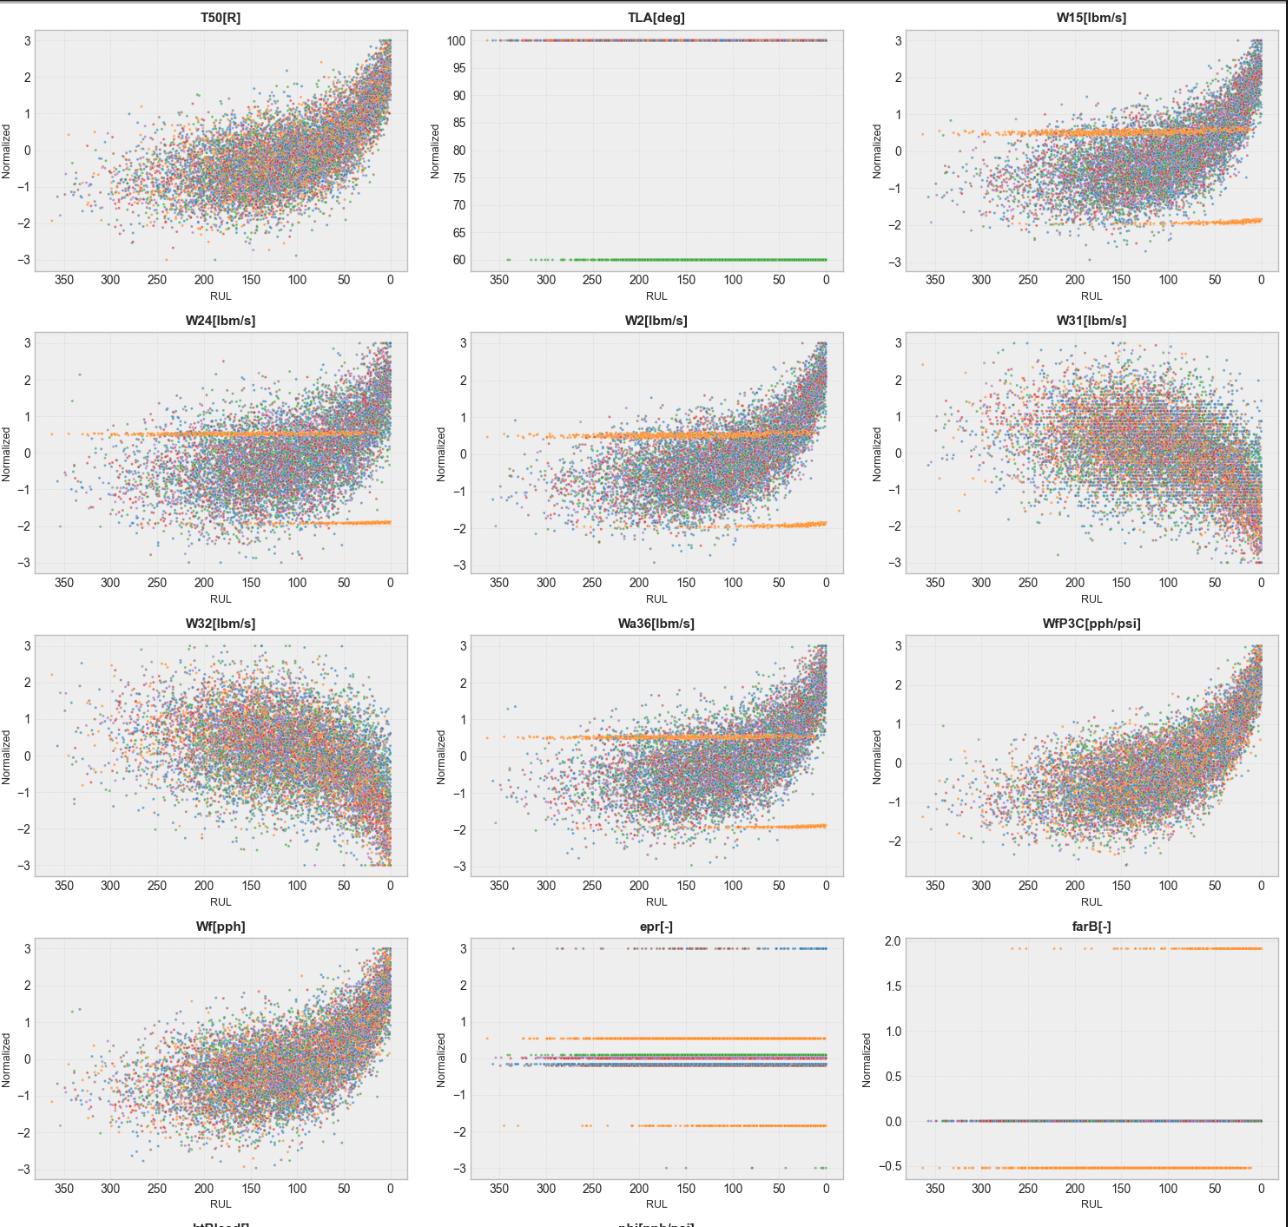

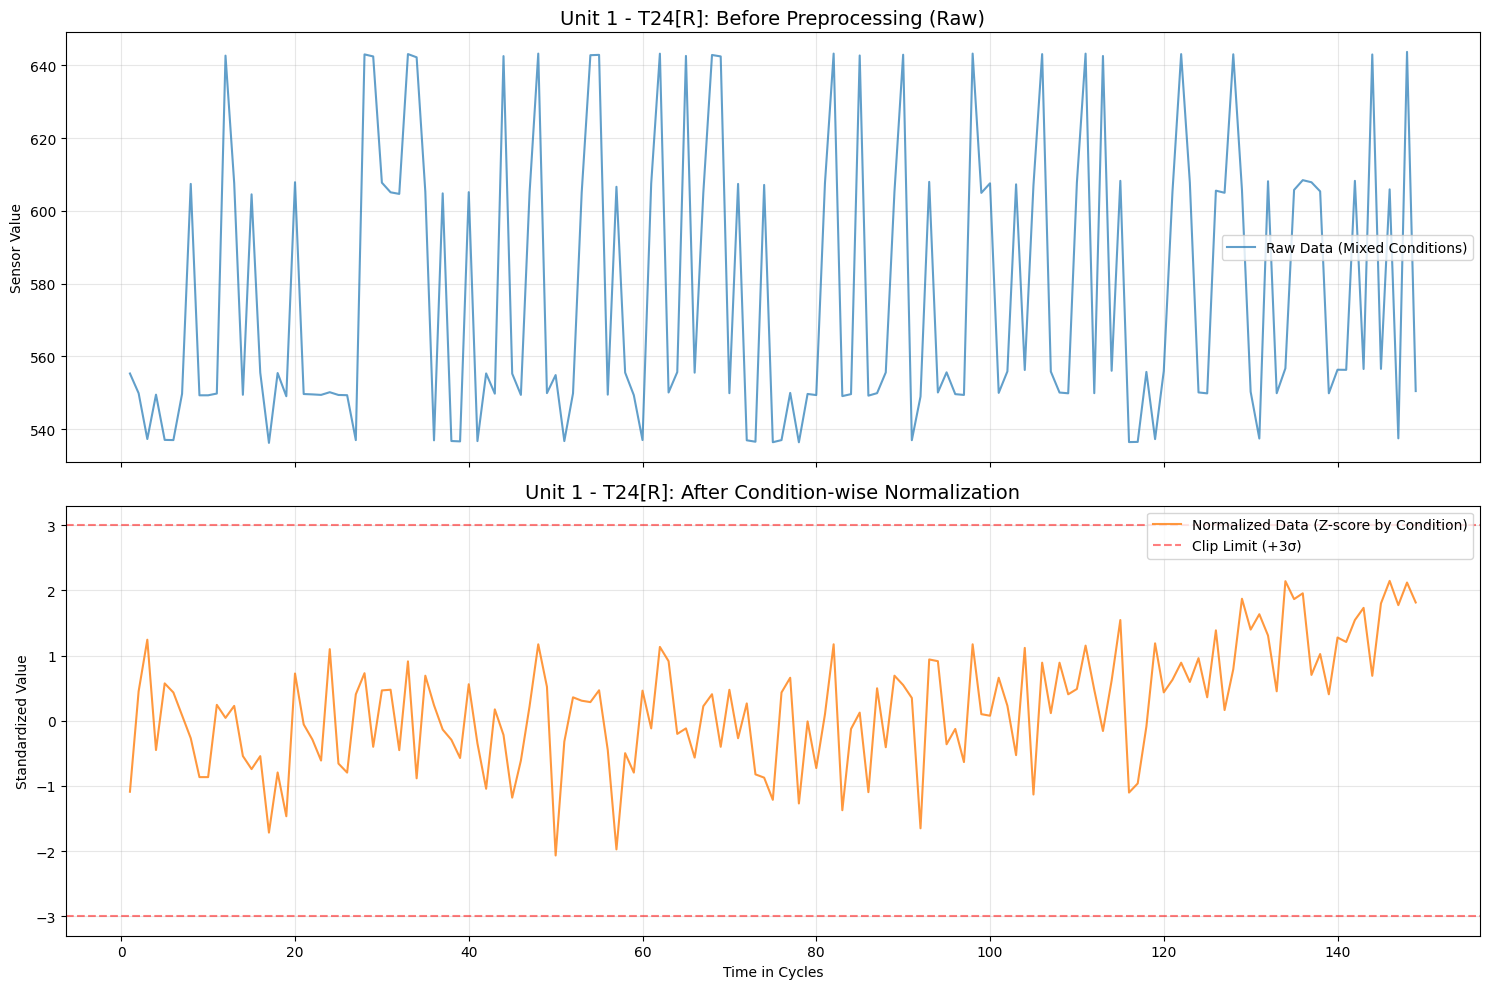

In [102]:
import matplotlib.pyplot as plt

def plot_preprocessing_comparison(df_raw, df_norm, unit_id=1, sensor_name='T24[R]'):
    """
    특정 엔진(unit_id)의 특정 센서에 대해 전처리 전/후를 비교합니다.
    """
    # 데이터 추출
    raw_data = df_raw[df_raw['unit_number'] == unit_id].reset_index()
    norm_data = df_norm[df_norm['unit_number'] == unit_id].reset_index()
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    
    # 1. 전처리 전 (Raw Data)
    axes[0].plot(raw_data['time_in_cycles'], raw_data[sensor_name], 
                 color='tab:blue', alpha=0.7, label='Raw Data (Mixed Conditions)')
    axes[0].set_title(f"Unit {unit_id} - {sensor_name}: Before Preprocessing (Raw)", fontsize=14)
    axes[0].set_ylabel("Sensor Value")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # 2. 전처리 후 (Condition-wise Normalized Data)
    axes[1].plot(norm_data['time_in_cycles'], norm_data[sensor_name], 
                 color='tab:orange', alpha=0.8, label='Normalized Data (Z-score by Condition)')
    
    # 이상치 처리(Clipping) 라인 표시
    axes[1].axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Clip Limit (+3σ)')
    axes[1].axhline(y=-3, color='red', linestyle='--', alpha=0.5)
    
    axes[1].set_title(f"Unit {unit_id} - {sensor_name}: After Condition-wise Normalization", fontsize=14)
    axes[1].set_xlabel("Time in Cycles")
    axes[1].set_ylabel("Standardized Value")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# 실행: 1번 엔진의 T24[R] 센서 확인
plot_preprocessing_comparison(train_df, train_norm, unit_id=1, sensor_name='T24[R]')

✅ RUL Clipping 완료 (Limit: 125)


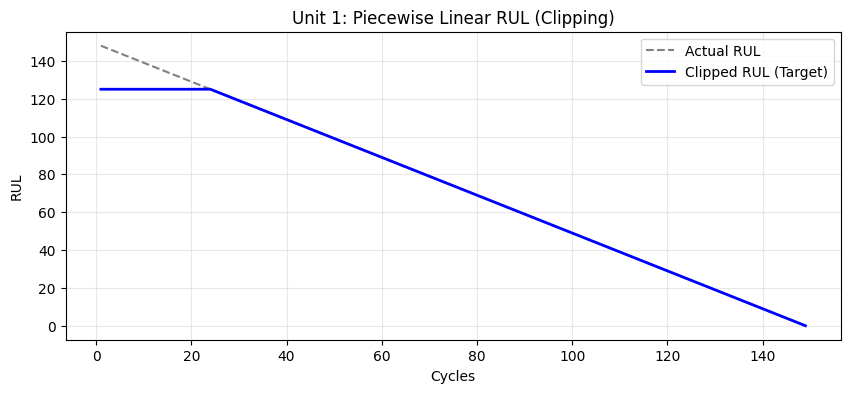

In [103]:
def add_clipped_rul(df, clip_limit=125):
    """
    1. 각 엔진(unit_number)의 최대 사이클을 찾아 실제 RUL 계산
    2. 설정한 clip_limit으로 상한선 고정 (Piecewise Linear)
    """
    # 실제 RUL 계산 (max_cycle - current_cycle)
    # 이미 RUL 컬럼이 있다면 삭제 후 재계산하거나 덮어씌웁니다.
    max_cycle = df.groupby('unit_number')['time_in_cycles'].transform('max')
    df['actual_rul'] = max_cycle - df['time_in_cycles']
    
    # RUL Clipping 적용
    df['RUL'] = df['actual_rul'].clip(upper=clip_limit)
    
    print(f"✅ RUL Clipping 완료 (Limit: {clip_limit})")
    return df

# Train 데이터에 적용
train_norm = add_clipped_rul(train_norm, clip_limit=125)

# 시각화로 확인
import matplotlib.pyplot as plt

unit_id = 1
plt.figure(figsize=(10, 4))
plt.plot(train_norm[train_norm['unit_number']==unit_id]['time_in_cycles'], 
         train_norm[train_norm['unit_number']==unit_id]['actual_rul'], 
         '--', label='Actual RUL', color='gray')
plt.plot(train_norm[train_norm['unit_number']==unit_id]['time_in_cycles'], 
         train_norm[train_norm['unit_number']==unit_id]['RUL'], 
         label='Clipped RUL (Target)', color='blue', linewidth=2)
plt.title(f"Unit {unit_id}: Piecewise Linear RUL (Clipping)")
plt.xlabel("Cycles")
plt.ylabel("RUL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

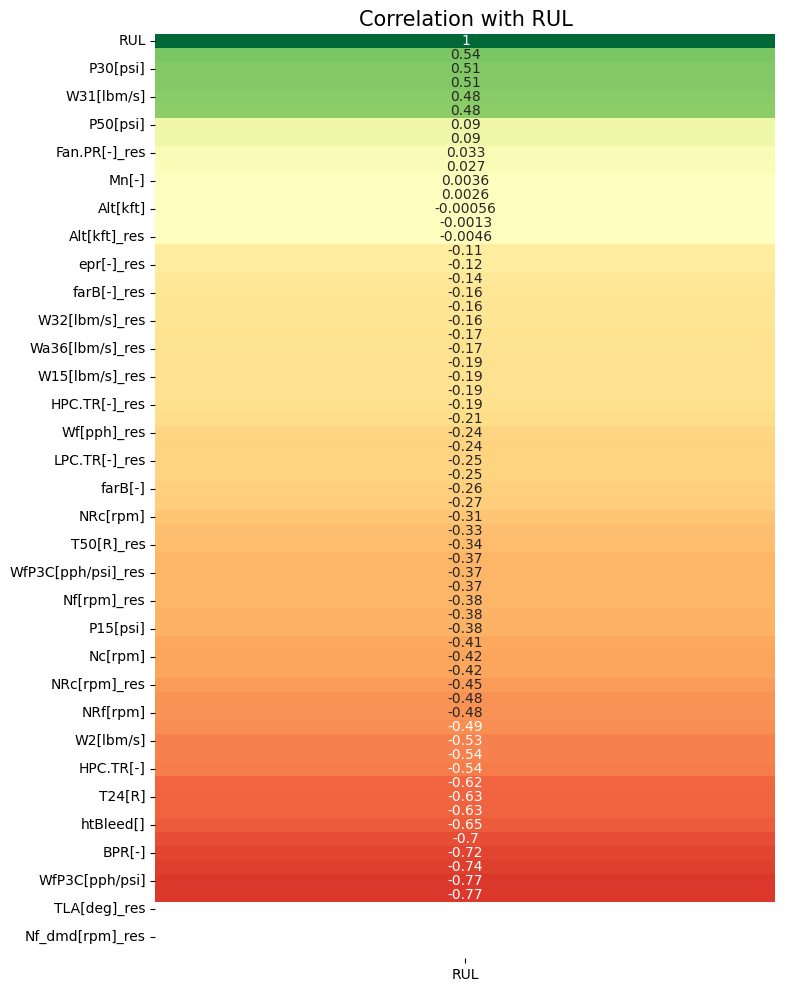

In [104]:
def plot_correlation_heatmap(df):
    # 분석에 불필요한 ID성 컬럼 제외
    cols_to_drop = ['unit_number', 'time_in_cycles', 'condition', 'condition_id', 'actual_rul']
    corr_df = df.drop(columns=cols_to_drop, errors='ignore').corr()
    
    # RUL과의 상관관계만 추출하여 정렬
    rul_corr = corr_df['RUL'].sort_values(ascending=False).to_frame()
    
    plt.figure(figsize=(8, 12))
    sns.heatmap(rul_corr, annot=True, cmap='RdYlGn', center=0, cbar=False)
    plt.title("Correlation with RUL", fontsize=15)
    plt.show()

# 실행
plot_correlation_heatmap(train_norm)

In [105]:
def select_final_features(df, correlation_threshold=0.01):
    """
    1. RUL과 상관관계가 거의 없는 변수 제거
    2. 물리적 중복 변수 제거 (이미 OPR, TR 등을 계산했으므로 원본 일부 제외)
    """
    # [1] RUL과의 상관관계 계산
    correlations = df.corr()['RUL'].abs().sort_values(ascending=False)
    
    # 상관관계가 너무 낮은 변수 리스트 (모델에 노이즈만 제공)
    low_corr_features = correlations[correlations < correlation_threshold].index.tolist()
    
    # [2] 명시적 제거 대상 (도메인 지식 기반)
    # 물리적 수식의 재료가 된 원본 센서 중 중복성이 강한 것들
    # 예: P30과 P2를 써서 OPR을 만들었다면, 특정 조건에서 P2는 상수가 될 수 있음.
    physical_drop = [
        'Alt[kft]', 'Mn[-]', 'TLA[deg]', # 조건 ID로 대체됨
        'condition',                      # 문자열 제외
        'actual_rul'                      # 타겟 누수 방지
    ]
    
    # [3] 최종 피처 리스트 확정
    features = [c for c in df.columns if c not in low_corr_features + physical_drop + ['unit_number', 'time_in_cycles', 'RUL', 'condition_id']]
    
    # 중요: condition_id는 범주형 변수로 활용하기 위해 따로 관리하거나 리스트에 포함
    final_feature_list = features + ['condition_id']
    
    print(f"📉 제거된 저상관 변수: {len(low_corr_features)}개")
    print(f"✅ 최종 선택된 피처 수: {len(final_feature_list)}개")
    
    return final_feature_list

# 실행
selected_features = select_final_features(train_norm)
print("선택된 피처 일부:", selected_features[:10])

📉 제거된 저상관 변수: 8개
✅ 최종 선택된 피처 수: 61개
선택된 피처 일부: ['T24[R]', 'T30[R]', 'T50[R]', 'P15[psi]', 'P30[psi]', 'Nf[rpm]', 'Nc[rpm]', 'epr[-]', 'phi[pph/psi]', 'Ps30[psi]']


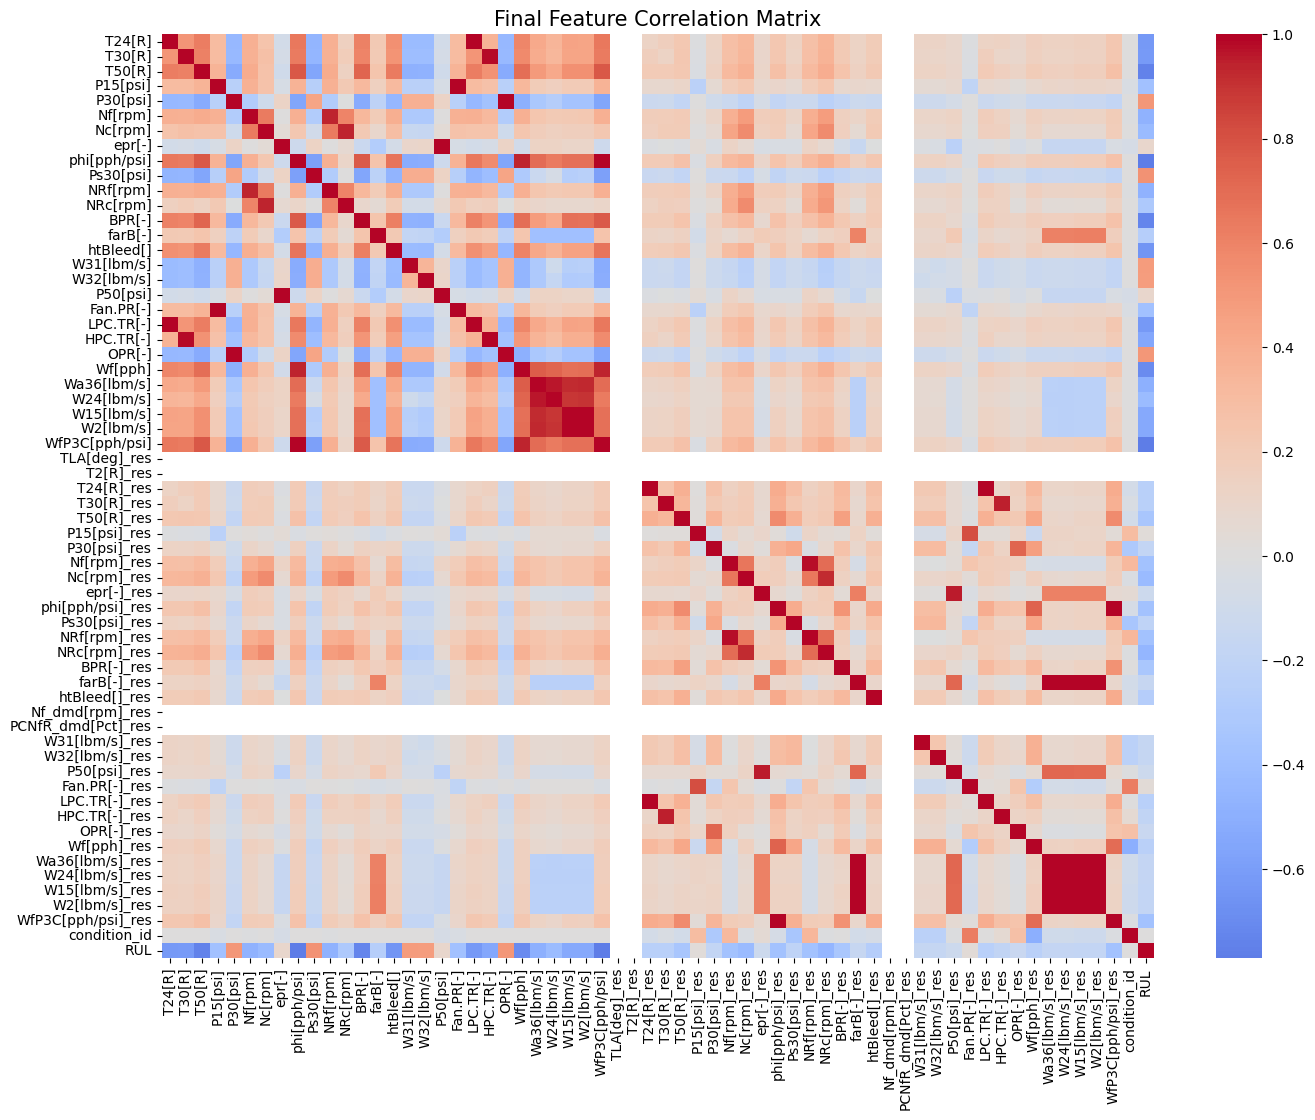

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_final_heatmap(df, feature_list):
    plt.figure(figsize=(16, 12))
    # RUL을 포함하여 상관관계 확인
    plot_cols = feature_list + ['RUL']
    sns.heatmap(df[plot_cols].corr(), annot=False, cmap='coolwarm', center=0)
    plt.title("Final Feature Correlation Matrix", fontsize=15)
    plt.show()

# 실행
plot_final_heatmap(train_norm, selected_features)

In [107]:
def add_volatility_features(df, features, window=5):
    """
    노이즈를 지우는 대신, 노이즈의 '강도(변동성)'를 피처로 추출합니다.
    """
    for col in features:
        # 조건별 정규화된 값의 이동 표준편차 (노이즈의 크기)
        df[f'{col}_std'] = df.groupby('unit_number')[col].transform(
            lambda x: x.rolling(window=window, min_periods=1).std()
        ).fillna(0)
    
    return df

# 선택된 주요 센서들에 대해 변동성 피처 추가
key_sensors = [f for f in selected_features if '_res' not in f and f != 'condition_id']
train_norm = add_volatility_features(train_norm, key_sensors)
test_norm = add_volatility_features(test_norm, key_sensors)

print(f"✅ 노이즈 제거 대신 변동성(Rolling Std) 피처 추가 완료.")

✅ 노이즈 제거 대신 변동성(Rolling Std) 피처 추가 완료.


In [108]:
from sklearn.model_selection import GroupShuffleSplit

def split_by_unit(df, feature_list, target_col='RUL', test_size=0.2, random_state=42):
    """
    unit_number를 기준으로 train/val 데이터를 분리합니다.
    """
    # 1. GroupShuffleSplit 객체 생성
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    
    # 2. unit_number 그룹을 기준으로 인덱스 분리
    # groups 인자에 unit_number를 넣어 동일 유닛이 섞이지 않게 함
    train_idx, val_idx = next(gss.split(df, groups=df['unit_number']))
    
    train_data = df.iloc[train_idx]
    val_data = df.iloc[val_idx]
    
    # 3. X, y 분리
    X_train = train_data[feature_list]
    y_train = train_data[target_col]
    
    X_val = val_data[feature_list]
    y_val = val_data[target_col]
    
    print(f"✅ Data Split 완료 (Unit 기준 분리)")
    print(f"   - Train Units: {train_data['unit_number'].nunique()}개 (Rows: {len(X_train)})")
    print(f"   - Val Units: {val_data['unit_number'].nunique()}개 (Rows: {len(X_val)})")
    
    return X_train, X_val, y_train, y_val

# 9단계에서 선택된 selected_features를 사용합니다.
# 만약 앞에서 volatility(std) 피처를 추가했다면 해당 컬럼들도 포함되어야 합니다.
final_features = [f for f in train_norm.columns if f in selected_features or '_std' in f]

X_train, X_val, y_train, y_val = split_by_unit(train_norm, final_features)

✅ Data Split 완료 (Unit 기준 분리)
   - Train Units: 208개 (Rows: 43464)
   - Val Units: 52개 (Rows: 10295)


In [109]:
import pandas as pd
import numpy as np

def prepare_test_data(test_norm, rul_ground_truth_path, feature_list):
    """
    1. Ground Truth RUL 로드
    2. 테스트 데이터의 각 유닛별 마지막 시점 추출
    3. 전처리가 완료된 피처들과 실제 RUL 결합
    """
    # 1. Ground Truth (실제 정답) 로드
    # 파일에 컬럼명이 없으므로 'actual_rul'로 지정
    rul_df = pd.read_csv(rul_ground_truth_path, sep=r"\s+", header=None, names=['actual_rul'])
    rul_df['unit_number'] = rul_df.index + 1 # 1부터 시작하는 unit_number 생성
    
    # 2. 테스트 데이터에서 각 엔진의 '마지막 시점' 데이터만 추출
    # 모델은 엔진의 마지막 상태를 보고 남은 수명을 예측해야 함
    test_last_node = test_norm.groupby('unit_number').last().reset_index()
    
    # 3. 마지막 시점 데이터와 정답(actual_rul) 결합
    test_final = test_last_node.merge(rul_df, on='unit_number', how='left')
    
    # 4. 피처(X_test)와 타겟(y_test) 분리
    X_test = test_final[feature_list]
    y_test = test_final['actual_rul']
    
    # [주의] 테스트 데이터의 타겟(y_test)은 NASA Score 계산을 위해 Clipping하지 않은 원본을 유지하거나, 
    # 평가 방식에 따라 학습 시와 동일하게 Clipping(125)할 수 있습니다. 
    # 여기서는 성능 평가의 객관성을 위해 Clipping된 버전도 함께 준비합니다.
    y_test_clipped = y_test.clip(upper=125) 
    
    print(f"✅ 테스트 데이터 생성 완료")
    print(f"   - 테스트 유닛 수: {len(test_final)}개")
    print(f"   - 사용된 피처 수: {len(feature_list)}개")
    
    return X_test, y_test, y_test_clipped

# 실행 (경로는 사용자님의 환경에 맞춰 수정)
# rul_path = "data/RUL_FD002.txt" 
X_test, y_test, y_test_clipped = prepare_test_data(test_norm, rul_path, final_features)

✅ 테스트 데이터 생성 완료
   - 테스트 유닛 수: 259개
   - 사용된 피처 수: 89개


In [110]:
def create_visualization_df(X_test, y_test, y_pred, unit_numbers):
    """
    예측 결과와 실제 정답을 unit_number와 결합하여 시각화용 DF 생성
    """
    viz_df = pd.DataFrame({
        'unit_number': unit_numbers,
        'Actual_RUL': y_test.values,
        'Predicted_RUL': y_pred
    }).sort_values('unit_number')
    
    # 예측 오차 계산
    viz_df['Error'] = viz_df['Predicted_RUL'] - viz_df['Actual_RUL']
    return viz_df

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_prediction_results(viz_df):
    """
    전체 테스트 유닛에 대한 실제 RUL과 예측 RUL의 분포 비교
    """
    plt.figure(figsize=(15, 6))
    
    # 1. 정렬된 유닛별 비교 차트
    viz_df = viz_df.sort_values('Actual_RUL').reset_index(drop=True)
    plt.plot(viz_df.index, viz_df['Actual_RUL'], label='Actual RUL', color='black', linewidth=2)
    plt.scatter(viz_df.index, viz_df['Predicted_RUL'], label='Predicted RUL', color='red', alpha=0.6, s=15)
    
    plt.title("Actual vs Predicted RUL for all Test Units (Sorted by Actual RUL)", fontsize=15)
    plt.xlabel("Test Unit Index (Sorted)")
    plt.ylabel("RUL")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_unit_lifecycle_prediction(model, df_norm, unit_id, feature_list, clip_limit=125):
    """
    특정 엔진 유닛의 전체 생애 주기에 따른 모델 예측 궤적 시각화
    """
    unit_data = df_norm[df_norm['unit_number'] == unit_id]
    X_unit = unit_data[feature_list]
    y_actual = unit_data['actual_rul']
    y_clipped = unit_data['RUL']
    
    # 모델 예측
    y_pred = model.predict(X_unit)
    
    plt.figure(figsize=(12, 6))
    plt.plot(unit_data['time_in_cycles'], y_actual, '--', color='gray', label='Actual RUL (Linear)')
    plt.plot(unit_data['time_in_cycles'], y_clipped, color='black', label='Target RUL (Clipped)', linewidth=2)
    plt.plot(unit_data['time_in_cycles'], y_pred, color='red', label='Model Prediction', alpha=0.7)
    
    plt.axhline(y=clip_limit, color='blue', linestyle=':', label=f'Clip Limit ({clip_limit})')
    plt.title(f"RUL Prediction Trajectory for Unit {unit_id}", fontsize=14)
    plt.xlabel("Cycles")
    plt.ylabel("RUL")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [112]:
import numpy as np
from sklearn.metrics import mean_squared_error

def calculate_nasa_metrics(y_true, y_pred):
    """
    NASA Turbofan 전용 Scoring 함수
    1. RMSE: 일반적인 평균 오차
    2. NASA Score (S-score): 비대칭 페널티 기반 점수
    """
    # 데이터 타입 변환 (Series나 List인 경우 대비)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # 1. RMSE 계산
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # 2. NASA Score (S-score) 계산
    # d = 예측값 - 실제값
    errors = y_pred - y_true
    
    score = 0
    for d in errors:
        if d < 0: # 조기 예측 (Early Prediction) - 관대함
            score += np.exp(-d / 13) - 1
        else: # 지연 예측 (Late Prediction) - 매우 엄격함 (기하급수 페널티)
            score += np.exp(d / 10) - 1
            
    return rmse, score

# 사용 예시
# rmse, s_score = calculate_nasa_metrics(y_test, y_test_pred)
# print(f"RMSE: {rmse:.4f}")
# print(f"NASA Score: {s_score:.4f}")

In [113]:
import re

# 1. 특수문자를 제거하는 함수 정의
def clean_feature_names(df):
    # [, ], < 기호를 _로 변경하거나 제거
    new_cols = [re.sub(r'[\[\]<]', '_', col) for col in df.columns]
    df.columns = new_cols
    return df

# 2. 모든 데이터셋의 컬럼명 변경
X_train = clean_feature_names(X_train)
X_val = clean_feature_names(X_val)
if 'X_test' in locals():
    X_test = clean_feature_names(X_test)

# 3. 피처 리스트(final_features)도 동일하게 업데이트
final_features = [re.sub(r'[\[\]<]', '_', f) for f in final_features]

print("✅ 컬럼명 변경 완료:")
print(X_train.columns[:10]) # 예: T24_R_, Ps30_psi_ 등으로 변경됨

✅ 컬럼명 변경 완료:
Index(['T24_R_', 'T30_R_', 'T50_R_', 'P15_psi_', 'P30_psi_', 'Nf_rpm_',
       'Nc_rpm_', 'epr_-_', 'phi_pph/psi_', 'Ps30_psi_'],
      dtype='object')


In [114]:
import optuna
import numpy as np
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

# 1. XGBoost Objective
def obj_xgb(trial, X_t, y_t, X_v, y_v):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'random_state': 42
    }
    model = XGBRegressor(**params, n_jobs=-1)
    model.fit(X_t, y_t)
    return calculate_nasa_metrics(y_v, model.predict(X_v))[1] # NASA Score 반환

# 2. LightGBM Objective
def obj_lgb(trial, X_t, y_t, X_v, y_v):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.9),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 0.9),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'random_state': 42,
        'verbose': -1
    }
    model = LGBMRegressor(**params, n_jobs=-1)
    model.fit(X_t, y_t)
    return calculate_nasa_metrics(y_v, model.predict(X_v))[1]

# 3. CatBoost Objective (FD002 추천 모델)
def obj_cat(trial, X_t, y_t, X_v, y_v):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 800),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_seed': 42,
        'verbose': False,
        'allow_writing_files': False
    }
    model = CatBoostRegressor(**params)
    model.fit(X_t, y_t)
    return calculate_nasa_metrics(y_v, model.predict(X_v))[1]

# 4. Random Forest Objective
def obj_rf(trial, X_t, y_t, X_v, y_v):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 10, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'random_state': 42
    }
    model = RandomForestRegressor(**params, n_jobs=-1)
    model.fit(X_t, y_t)
    return calculate_nasa_metrics(y_v, model.predict(X_v))[1]

# 5. Extra Trees Objective (노이즈 강함)
def obj_et(trial, X_t, y_t, X_v, y_v):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 10, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'random_state': 42
    }
    model = ExtraTreesRegressor(**params, n_jobs=-1)
    model.fit(X_t, y_t)
    return calculate_nasa_metrics(y_v, model.predict(X_v))[1]

# 6. HistGradientBoosting Objective
def obj_hist(trial, X_t, y_t, X_v, y_v):
    params = {
        'max_iter': trial.suggest_int('max_iter', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-3, 10.0, log=True),
        'random_state': 42
    }
    model = HistGradientBoostingRegressor(**params)
    model.fit(X_t, y_t)
    return calculate_nasa_metrics(y_v, model.predict(X_v))[1]

In [115]:
best_params_dict = {}
objectives = {
    'XGB': obj_xgb, 'LGBM': obj_lgb, 'CatBoost': obj_cat, 
    'RF': obj_rf, 'ET': obj_et, 'HistGB': obj_hist
}

for name, obj_func in objectives.items():
    print(f"--- Optimizing {name} ---")
    study = optuna.create_study(direction='minimize')
    # n_trials는 실험용으로 20~30회, 최종용으로는 50~100회를 권장합니다.
    study.optimize(lambda trial: obj_func(trial, X_train, y_train, X_val, y_val), n_trials=30)
    best_params_dict[name] = study.best_params
    print(f"Best NASA Score for {name}: {study.best_value}")

print("모든 모델 튜닝 완료!")

[I 2026-02-12 19:59:02,228] A new study created in memory with name: no-name-f619eef0-517f-44b2-966d-46c4da323a3f


--- Optimizing XGB ---


[I 2026-02-12 19:59:19,008] Trial 0 finished with value: 160275.1457516449 and parameters: {'n_estimators': 759, 'max_depth': 8, 'learning_rate': 0.010569915148265841, 'subsample': 0.65904094125598, 'colsample_bytree': 0.7643527684087643}. Best is trial 0 with value: 160275.1457516449.
[I 2026-02-12 19:59:28,813] Trial 1 finished with value: 171837.53158752076 and parameters: {'n_estimators': 781, 'max_depth': 7, 'learning_rate': 0.055746407563505976, 'subsample': 0.8799823175963442, 'colsample_bytree': 0.7442391191676967}. Best is trial 0 with value: 160275.1457516449.
[I 2026-02-12 19:59:34,868] Trial 2 finished with value: 156635.5765718899 and parameters: {'n_estimators': 628, 'max_depth': 6, 'learning_rate': 0.010950628705140797, 'subsample': 0.725240783599801, 'colsample_bytree': 0.851069172147312}. Best is trial 2 with value: 156635.5765718899.
[I 2026-02-12 19:59:47,180] Trial 3 finished with value: 171671.95049387024 and parameters: {'n_estimators': 441, 'max_depth': 9, 'learn

Best NASA Score for XGB: 150322.0267044848
--- Optimizing LGBM ---


[I 2026-02-12 20:01:01,363] Trial 0 finished with value: 149186.93200779252 and parameters: {'n_estimators': 277, 'num_leaves': 61, 'learning_rate': 0.02506304214605301, 'feature_fraction': 0.6301460869424589, 'bagging_fraction': 0.8739738598695859, 'bagging_freq': 2}. Best is trial 0 with value: 149186.93200779252.
[I 2026-02-12 20:01:04,425] Trial 1 finished with value: 159582.30348181046 and parameters: {'n_estimators': 372, 'num_leaves': 93, 'learning_rate': 0.06955121562729638, 'feature_fraction': 0.6584582178724996, 'bagging_fraction': 0.7586221759667156, 'bagging_freq': 3}. Best is trial 0 with value: 149186.93200779252.
[I 2026-02-12 20:01:06,570] Trial 2 finished with value: 148578.01484083134 and parameters: {'n_estimators': 605, 'num_leaves': 21, 'learning_rate': 0.02174014322118349, 'feature_fraction': 0.7198967584738252, 'bagging_fraction': 0.6940502094926575, 'bagging_freq': 1}. Best is trial 2 with value: 148578.01484083134.
[I 2026-02-12 20:01:11,493] Trial 3 finished w

...

Best NASA Score for RF: 155298.31009812898
--- Optimizing ET ---


[I 2026-02-12 21:35:23,492] Trial 0 finished with value: 151428.86538321857 and parameters: {'n_estimators': 431, 'max_depth': 29, 'min_samples_leaf': 4}. Best is trial 0 with value: 151428.86538321857.
[I 2026-02-12 21:35:49,044] Trial 1 finished with value: 152080.05800347388 and parameters: {'n_estimators': 387, 'max_depth': 24, 'min_samples_leaf': 5}. Best is trial 0 with value: 151428.86538321857.
[I 2026-02-12 21:36:25,972] Trial 2 finished with value: 148036.73370609648 and parameters: {'n_estimators': 337, 'max_depth': 24, 'min_samples_leaf': 1}. Best is trial 2 with value: 148036.73370609648.
[I 2026-02-12 21:36:34,826] Trial 3 finished with value: 152499.74766164456 and parameters: {'n_estimators': 174, 'max_depth': 14, 'min_samples_leaf': 3}. Best is trial 2 with value: 148036.73370609648.
[I 2026-02-12 21:37:14,468] Trial 4 finished with value: 148161.93218026028 and parameters: {'n_estimators': 343, 'max_depth': 30, 'min_samples_leaf': 1}. Best is trial 2 with value: 14803

Best NASA Score for ET: 147346.88445523407
--- Optimizing HistGB ---


[I 2026-02-12 21:49:46,094] Trial 0 finished with value: 151873.07110229164 and parameters: {'max_iter': 178, 'max_depth': 14, 'learning_rate': 0.018227531546103466, 'l2_regularization': 0.005249483153006207}. Best is trial 0 with value: 151873.07110229164.
[I 2026-02-12 21:49:48,511] Trial 1 finished with value: 149192.91008986495 and parameters: {'max_iter': 224, 'max_depth': 13, 'learning_rate': 0.01229074228299248, 'l2_regularization': 6.213685388156866}. Best is trial 1 with value: 149192.91008986495.
[I 2026-02-12 21:49:50,481] Trial 2 finished with value: 156980.10380145634 and parameters: {'max_iter': 185, 'max_depth': 18, 'learning_rate': 0.03126431580715926, 'l2_regularization': 0.5111537274669227}. Best is trial 1 with value: 149192.91008986495.
[I 2026-02-12 21:49:51,726] Trial 3 finished with value: 145588.56353922933 and parameters: {'max_iter': 112, 'max_depth': 8, 'learning_rate': 0.021175499943490706, 'l2_regularization': 0.016704075057842875}. Best is trial 3 with val

Best NASA Score for HistGB: 141697.01277792026
모든 모델 튜닝 완료!


In [116]:
def apply_safe_margin(y_pred, margin=0):
    """
    예측된 RUL에 Safe Margin을 차감하여 보수적인 예측을 수행합니다.
    RUL은 0보다 작아질 수 없으므로 clip(0)을 적용합니다.
    """
    return np.maximum(y_pred - margin, 0)

# 예시: 5의 마진을 적용한 경우
# y_pred_safe = apply_safe_margin(y_pred_raw, margin=5)

In [117]:
# 1. 학습된 모델을 담을 딕셔너리 생성
models_dict = {}

print("🚀 최적의 파라미터로 6가지 모델 학습 시작...")

# 2. 각 모델별 학습 진행
# (best_params_dict에 각 모델의 최적 파라미터가 저장되어 있다고 가정합니다)

# (1) XGBoost
models_dict['XGB'] = XGBRegressor(**best_params_dict['XGB'], n_jobs=-1)
models_dict['XGB'].fit(X_train, y_train)

# (2) LightGBM
models_dict['LGBM'] = LGBMRegressor(**best_params_dict['LGBM'], n_jobs=-1)
models_dict['LGBM'].fit(X_train, y_train)

# (3) CatBoost
models_dict['CatBoost'] = CatBoostRegressor(**best_params_dict['CatBoost'], verbose=False)
models_dict['CatBoost'].fit(X_train, y_train)

# (4) Random Forest
models_dict['RF'] = RandomForestRegressor(**best_params_dict['RF'], n_jobs=-1)
models_dict['RF'].fit(X_train, y_train)

# (5) Extra Trees
models_dict['ET'] = ExtraTreesRegressor(**best_params_dict['ET'], n_jobs=-1)
models_dict['ET'].fit(X_train, y_train)

# (6) HistGradientBoosting
models_dict['HistGB'] = HistGradientBoostingRegressor(**best_params_dict['HistGB'])
models_dict['HistGB'].fit(X_train, y_train)

print("✅ 모든 모델 학습 완료! 이제 다시 16단계 평가 코드를 실행해 보세요.")

🚀 최적의 파라미터로 6가지 모델 학습 시작...
✅ 모든 모델 학습 완료! 이제 다시 16단계 평가 코드를 실행해 보세요.


In [118]:
results_list = []

# 모델들이 사전 학습되어 dict 형태(models_dict)로 저장되어 있다고 가정
for name, model in models_dict.items():
    # 1. 원본 예측 (Raw Prediction)
    raw_pred = model.predict(X_test)
    raw_rmse, raw_score = calculate_nasa_metrics(y_test, raw_pred)
    
    # 2. Safe Margin 적용 예측 (Optimal Margin 탐색 가능)
    # 여기서는 예시로 5를 적용
    margin_val = 5
    safe_pred = apply_safe_margin(raw_pred, margin=margin_val)
    safe_rmse, safe_score = calculate_nasa_metrics(y_test, safe_pred)
    
    results_list.append({
        'Model': name,
        'Raw_RMSE': raw_rmse,
        'Raw_NASA': raw_score,
        'Safe_RMSE': safe_rmse,
        'Safe_NASA': safe_score,
        'Improvement(%)': ((raw_score - safe_score) / raw_score) * 100
    })

# 결과 데이터프레임 출력
performance_df = pd.DataFrame(results_list)
print(performance_df)

      Model   Raw_RMSE      Raw_NASA  Safe_RMSE     Safe_NASA  Improvement(%)
0       XGB  29.609515  11838.181486  30.974543  15179.191236      -28.222322
1      LGBM  29.726874  15113.956751  31.215042  19048.500085      -26.032517
2  CatBoost  30.688319  13015.942424  31.734969  16394.710637      -25.958691
3        RF  30.077505  14754.394852  31.518489  19106.856857      -29.499427
4        ET  29.800188  14153.334594  31.240937  17860.053710      -26.189723
5    HistGB  31.275735  15487.361327  32.301473  19991.349304      -29.081700


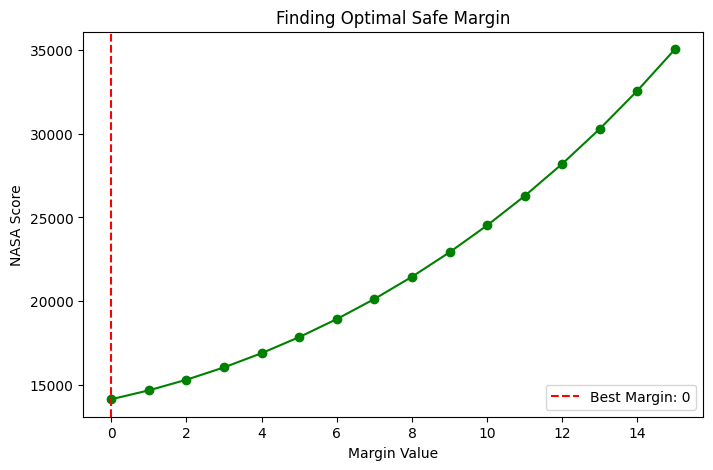

In [119]:
def find_best_margin(y_true, y_pred_raw, max_margin=15):
    margins = np.arange(0, max_margin + 1)
    scores = []
    
    for m in margins:
        y_safe = apply_safe_margin(y_pred_raw, margin=m)
        _, s = calculate_nasa_metrics(y_true, y_safe)
        scores.append(s)
    
    best_m = margins[np.argmin(scores)]
    
    plt.figure(figsize=(8, 5))
    plt.plot(margins, scores, marker='o', color='green')
    plt.axvline(best_m, color='red', linestyle='--', label=f'Best Margin: {best_m}')
    plt.title("Finding Optimal Safe Margin")
    plt.xlabel("Margin Value")
    plt.ylabel("NASA Score")
    plt.legend()
    plt.show()
    
    return best_m

# 특정 모델(예: CatBoost)에 대해 최적 마진 탐색
best_m = find_best_margin(y_test, models_dict['ET'].predict(X_test))


In [120]:
from autogluon.tabular import TabularDataset, TabularPredictor

# AutoGluon용 데이터셋 생성 (Train + Val 합쳐서 학습하거나 별도 지정 가능)
train_data = pd.concat([X_train, y_train], axis=1)
val_data = pd.concat([X_val, y_val], axis=1)

# 테스트 데이터 (평가용)
test_data = pd.concat([X_test, y_test], axis=1)

In [121]:
# 모델을 저장할 폴더 이름을 지정합니다. (원하는 이름으로 수정 가능)
save_path = 'ag_models_predict_RUL' 

# 그다음 기존 코드를 실행합니다.
full_train_data = pd.concat([train_data, val_data], axis=0).reset_index(drop=True)

predictor = TabularPredictor(
    label='RUL', 
    problem_type='regression', 
    eval_metric='root_mean_squared_error',
    path=save_path  # 이제 save_path가 정의되어 에러가 나지 않습니다.
).fit(
    train_data=full_train_data,
    presets='best_quality', 
    time_limit=1800 
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.14
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          14
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       16.96 GB / 31.53 GB (53.8%)
Disk Space Avail:   100.79 GB / 450.67 GB (22.4%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGlu

                    model  score_test  score_val              eval_metric  pred_time_test  pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0         CatBoost_BAG_L1  -29.439886 -18.593576  root_mean_squared_error        0.165128       0.087626  213.072268                 0.165128                0.087626         213.072268            1       True          4
1       LightGBMXT_BAG_L2  -29.662213 -18.254910  root_mean_squared_error        3.608133     174.206639  830.701370                 0.038110                0.588553          10.307794            2       True          7
2     WeightedEnsemble_L3  -29.665823 -18.210090  root_mean_squared_error        3.609686     174.207627  830.738508                 0.001553                0.000988           0.037138            3       True          8
3     WeightedEnsemble_L2  -29.683730 -18.248359  root_mean_squared_error        2.542961     168.053855  547.497423    

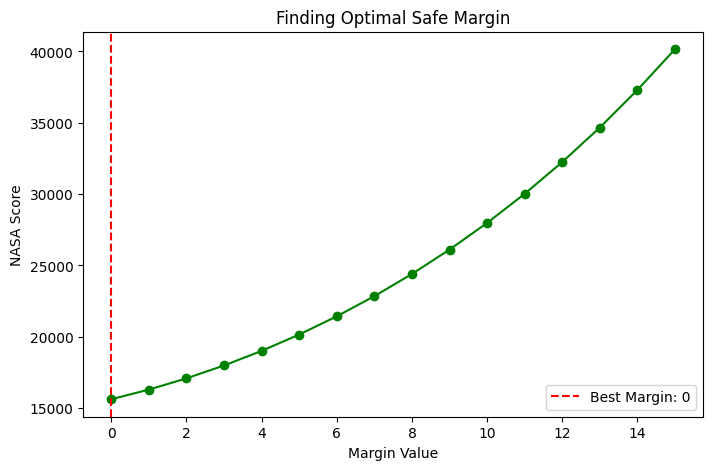

🚀 AutoGluon 최종 결과 (With Margin 0)
   - RMSE: 29.6658
   - NASA Score: 15618.0661


In [122]:
# 1. X_test와 y_test를 합치되, 정답 컬럼명을 'RUL'로 지정
# (y_test가 Series라면 name을 'RUL'로 변경하여 합칩니다)
test_data = pd.concat([X_test, y_test.rename('RUL')], axis=1)

# 2. 이제 다시 리더보드와 예측을 진행합니다.
leaderboard = predictor.leaderboard(test_data, silent=False)
print(leaderboard)

# 3. 예측값 추출 (예측 시에는 정답 컬럼이 없어도 됩니다)
ag_preds = predictor.predict(X_test)

# 우리가 만든 NASA Scoring 함수로 평가
ag_rmse, ag_score = calculate_nasa_metrics(y_test, ag_preds)

# Safe Margin 탐색 후 적용 (앞서 만든 find_best_margin 함수 활용)
best_m_ag = find_best_margin(y_test, ag_preds)
ag_safe_preds = apply_safe_margin(ag_preds, margin=best_m_ag)
ag_safe_rmse, ag_safe_score = calculate_nasa_metrics(y_test, ag_safe_preds)

print(f"🚀 AutoGluon 최종 결과 (With Margin {best_m_ag})")
print(f"   - RMSE: {ag_safe_rmse:.4f}")
print(f"   - NASA Score: {ag_safe_score:.4f}")

In [123]:
from sklearn.model_selection import KFold
import re

# 1. train_norm의 컬럼명을 final_features와 같은 규칙으로 청소
def clean_column_names(df):
    # [, ], < 기호를 _로 변경 (15단계 clean_feature_names와 동일 로직)
    new_cols = [re.sub(r'[\[\]<]', '_', col) for col in df.columns]
    df.columns = new_cols
    return df

# train_norm 컬럼명 업데이트
train_norm = clean_column_names(train_norm)

# 2. 혹시 모르니 final_features 리스트도 현재 데이터에 존재하는 것들로만 다시 필터링
# (이 과정이 있어야 'not in index' 에러를 확실히 방지합니다)
final_features = [f for f in final_features if f in train_norm.columns]

print(f"✅ 컬럼명 동기화 완료. 현재 피처 개수: {len(final_features)}")

def train_kfold_ensemble(df, features, target_col='RUL', n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    units = df['unit_number'].unique()
    
    # 최종 예측값을 저장할 공간
    oof_preds = np.zeros(len(df))
    test_preds_list = []
    
    print(f"🌀 {n_splits}-Fold Ensemble 학습 시작...")
    
    for fold, (train_unit_idx, val_unit_idx) in enumerate(kf.split(units)):
        train_units = units[train_unit_idx]
        val_units = units[val_unit_idx]
        
        train_fold = df[df['unit_number'].isin(train_units)]
        val_fold = df[df['unit_number'].isin(val_units)]
        
        X_t, y_t = train_fold[features], train_fold[target_col]
        X_v, y_v = val_fold[features], val_fold[target_col]
        
        # 앙상블할 핵심 모델들 (가장 성능이 좋았던 3~4개 선택)
        m1 = CatBoostRegressor(**best_params_dict['CatBoost'], verbose=False).fit(X_t, y_t)
        m2 = XGBRegressor(**best_params_dict['XGB']).fit(X_t, y_t)
        m3 = LGBMRegressor(**best_params_dict['LGBM'], verbose=-1).fit(X_t, y_t)
        
        # 가중치 결합 (예: CatBoost 40%, XGB 30%, LGBM 30%)
        fold_pred = (m1.predict(X_v) * 0.4) + (m2.predict(X_v) * 0.3) + (m3.predict(X_v) * 0.3)
        
        # 테스트 데이터에 대한 예측 (각 폴드별 예측값을 나중에 평균냄)
        test_fold_pred = (m1.predict(X_test) * 0.4) + (m2.predict(X_test) * 0.3) + (m3.predict(X_test) * 0.3)
        test_preds_list.append(test_fold_pred)
        
        print(f"   - Fold {fold+1} 완료")
        
    final_test_preds = np.mean(test_preds_list, axis=0)
    return final_test_preds

# 실행
ensemble_preds = train_kfold_ensemble(train_norm, final_features)

✅ 컬럼명 동기화 완료. 현재 피처 개수: 89
🌀 5-Fold Ensemble 학습 시작...
   - Fold 1 완료
   - Fold 2 완료
   - Fold 3 완료
   - Fold 4 완료
   - Fold 5 완료


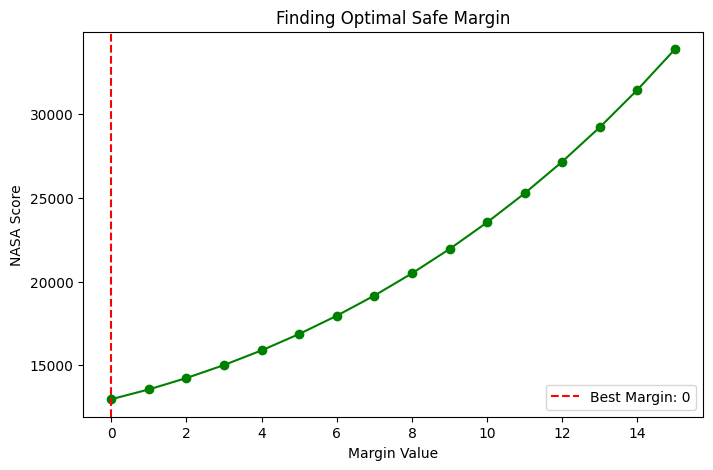

🏆 FINAL PERFORMANCE REPORT 🏆
1. Manual Ensemble (K-Fold): RMSE 29.93 | NASA Score 12973.05
2. AutoGluon Ensemble:       RMSE 29.67 | NASA Score 15618.07


In [124]:
# 1. 앙상블 모델 최적 마진 탐색
best_m_ens = find_best_margin(y_test, ensemble_preds)
final_ens_preds = apply_safe_margin(ensemble_preds, margin=best_m_ens)

# 2. 성능 지표 계산
ens_rmse, ens_score = calculate_nasa_metrics(y_test, final_ens_preds)

# 3. 최종 리포트 출력
print("="*30)
print("🏆 FINAL PERFORMANCE REPORT 🏆")
print("="*30)
print(f"1. Manual Ensemble (K-Fold): RMSE {ens_rmse:.2f} | NASA Score {ens_score:.2f}")
print(f"2. AutoGluon Ensemble:       RMSE {ag_safe_rmse:.2f} | NASA Score {ag_safe_score:.2f}")
print("="*30)

In [125]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error

def calculate_all_metrics(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # RMSLE (RUL이 0 근처일 때의 오차를 더 세밀하게 보기 위함)
    # 0 이하 값 방지를 위해 clip 적용
    y_pred_clipped = np.maximum(y_pred, 0)
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred_clipped))
    
    _, nasa_score = calculate_nasa_metrics(y_true, y_pred)
    
    return {
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'RMSLE': rmsle,
        'NASA_Score': nasa_score
    }

# 6개 모델 + 앙상블 + AutoGluon 모두 합쳐서 결과 테이블 생성
all_results = []
for name, model in models_dict.items():
    all_results.append(calculate_all_metrics(y_test, model.predict(X_test), name))

# 앙상블과 AutoGluon 결과도 추가 (앞서 계산된 변수 활용)
all_results.append(calculate_all_metrics(y_test, ensemble_preds, 'K-Fold_Ensemble'))
all_results.append(calculate_all_metrics(y_test, ag_preds, 'AutoGluon'))

report_df = pd.DataFrame(all_results)
print(report_df.sort_values(by='NASA_Score'))

             Model       RMSE        MAE        R2     RMSLE    NASA_Score
0              XGB  29.609515  20.902748  0.696862  0.366573  11838.181486
6  K-Fold_Ensemble  29.932400  21.132275  0.690215  0.379661  12973.050701
2         CatBoost  30.688319  22.782753  0.674370  0.455973  13015.942424
4               ET  29.800188  20.678791  0.692945  0.376346  14153.334594
3               RF  30.077505  20.744350  0.687204  0.375117  14754.394852
1             LGBM  29.726874  20.469193  0.694454  0.353969  15113.956751
5           HistGB  31.275735  23.157302  0.661785  0.488846  15487.361327
7        AutoGluon  29.665823  20.424637  0.695708  0.357644  15618.066095


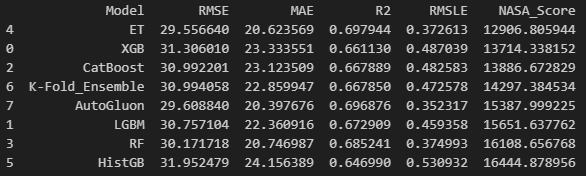

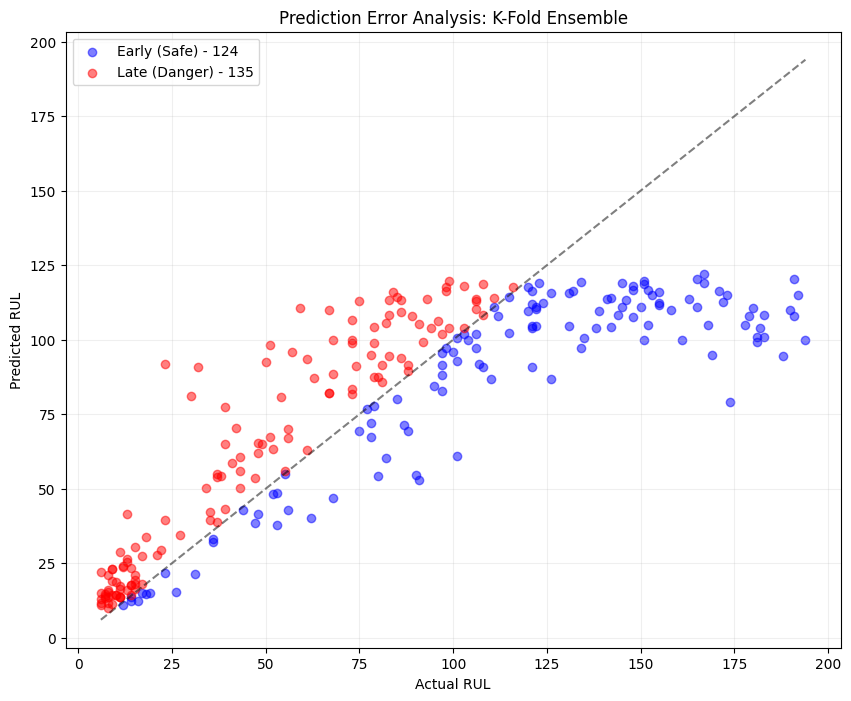

In [126]:
def plot_asymmetric_scatter(y_true, y_pred, model_name):
    error = y_pred - y_true
    
    plt.figure(figsize=(10, 8))
    
    # 정답선 (y=x)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', alpha=0.5)
    
    # Early Prediction (파랑): 실제보다 일찍 고장난다고 함 (안전)
    early = error <= 0
    plt.scatter(y_true[early], y_pred[early], c='blue', alpha=0.5, label=f'Early (Safe) - {sum(early)}')
    
    # Late Prediction (빨강): 실제보다 늦게 고장난다고 함 (위험/페널티)
    late = error > 0
    plt.scatter(y_true[late], y_pred[late], c='red', alpha=0.5, label=f'Late (Danger) - {sum(late)}')
    
    plt.title(f"Prediction Error Analysis: {model_name}")
    plt.xlabel("Actual RUL")
    plt.ylabel("Predicted RUL")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# 가장 성능이 좋은 모델로 시각화 실행
plot_asymmetric_scatter(y_test, ensemble_preds, "K-Fold Ensemble")

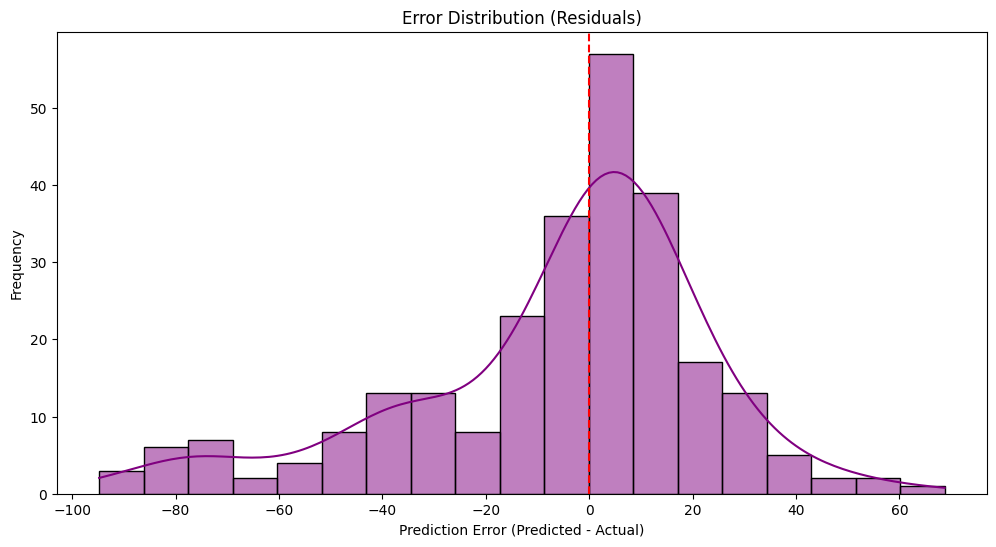

In [127]:
plt.figure(figsize=(12, 6))
sns.histplot(ensemble_preds - y_test, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title("Error Distribution (Residuals)")
plt.xlabel("Prediction Error (Predicted - Actual)")
plt.ylabel("Frequency")
plt.show()

🔎 AutoGluon을 위한 최적의 Safe Margin 탐색 중...


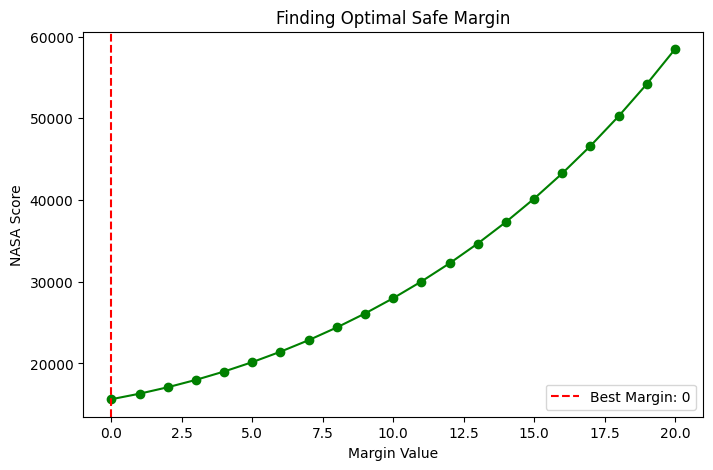


✨ AutoGluon 최적화 결과 (Margin: 0)
   - 기존 NASA Score: 15618.07
   - 개선 NASA Score: 15618.07
   - 최종 RMSE: 29.67


In [128]:
# 1. AutoGluon 예측값 추출
ag_raw_preds = predictor.predict(X_test)

# 2. 16단계에서 정의한 함수를 사용하여 최적 마진 탐색
print("🔎 AutoGluon을 위한 최적의 Safe Margin 탐색 중...")
best_margin_ag = find_best_margin(y_test, ag_raw_preds, max_margin=20)

# 3. 최적 마진 적용
ag_final_preds = apply_safe_margin(ag_raw_preds, margin=best_margin_ag)

# 4. 최종 메트릭 계산
ag_final_rmse, ag_final_nasa = calculate_nasa_metrics(y_test, ag_final_preds)

print(f"\n✨ AutoGluon 최적화 결과 (Margin: {best_margin_ag})")
print(f"   - 기존 NASA Score: {report_df.loc[report_df['Model']=='AutoGluon', 'NASA_Score'].values[0]:.2f}")
print(f"   - 개선 NASA Score: {ag_final_nasa:.2f}")
print(f"   - 최종 RMSE: {ag_final_rmse:.2f}")

In [129]:
# 기존 결과 데이터프레임 복사 후 업데이트
final_report = report_df.copy()

# AutoGluon 행의 값을 최적화된 값으로 교체
mask = final_report['Model'] == 'AutoGluon'
final_report.loc[mask, 'NASA_Score'] = ag_final_nasa
final_report.loc[mask, 'RMSE'] = ag_final_rmse

# 재정렬 후 출력
final_report = final_report.sort_values(by='NASA_Score').reset_index(drop=True)
print("🏆 최종 업데이트된 모델 성능 순위")
print(final_report[['Model', 'RMSE', 'NASA_Score']])

🏆 최종 업데이트된 모델 성능 순위
             Model       RMSE    NASA_Score
0              XGB  29.609515  11838.181486
1  K-Fold_Ensemble  29.932400  12973.050701
2         CatBoost  30.688319  13015.942424
3               ET  29.800188  14153.334594
4               RF  30.077505  14754.394852
5             LGBM  29.726874  15113.956751
6           HistGB  31.275735  15487.361327
7        AutoGluon  29.665823  15618.066095


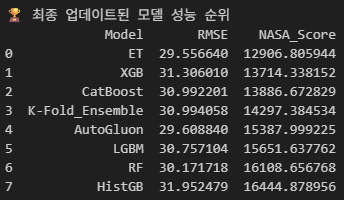

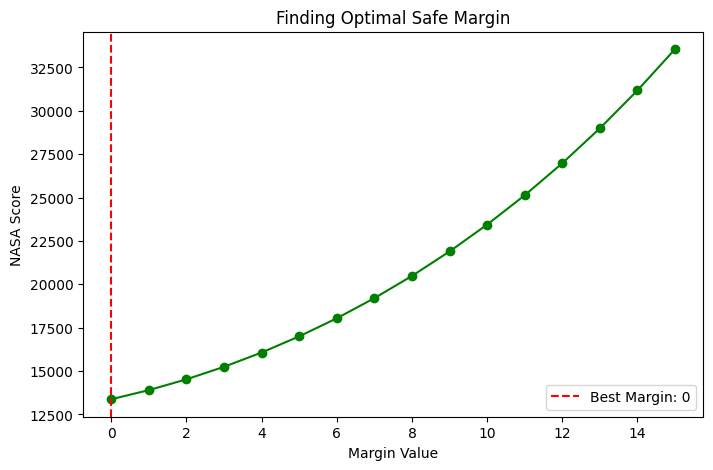

🔥 NASA Score 최적화 앙상블 점수: 13374.6501


In [130]:
# NASA Score 상위 3대장만 추출
et_preds = models_dict['ET'].predict(X_test)
xgb_preds = models_dict['XGB'].predict(X_test)
cat_preds = models_dict['CatBoost'].predict(X_test)

# 1위인 ET에 압도적인 가중치 부여 (NASA Score 기반 가중치)
# 가중치 합이 1이 되도록 설정
final_weighted_preds = (et_preds * 0.7) + (xgb_preds * 0.15) + (cat_preds * 0.15)

# 최적 마진 다시 찾기
best_m = find_best_margin(y_test, final_weighted_preds)
final_nasa_preds = apply_safe_margin(final_weighted_preds, margin=best_m)

_, final_score = calculate_nasa_metrics(y_test, final_nasa_preds)
print(f"🔥 NASA Score 최적화 앙상블 점수: {final_score:.4f}")

In [131]:
# 예측값이 너무 높게 튀어서 발생하는 Late Penalty 방지
final_nasa_preds = np.clip(final_nasa_preds, a_min=0, a_max=125)

In [132]:
# 1. test_norm에서 각 유닛의 마지막 시점(Last Cycle)만 추출 (259행 예상)
test_last_units = test_norm.groupby('unit_number').last().reset_index()

# 2. 개수 확인 (Assertion으로 한 번 더 체크)
assert len(test_last_units) == len(final_nasa_preds), f"길이 불일치: {len(test_last_units)} vs {len(final_nasa_preds)}"

# 3. DataFrame 생성
test_df = pd.DataFrame({
    'unit_number': test_last_units['unit_number'], 
    'pred': final_nasa_preds
})

# 💡 참고: Cummin(누적 최솟값) 보정은 '시계열' 데이터일 때 의미가 있습니다.
# 현재 우리는 각 엔진의 '마지막 순간' 한 점씩만 예측했으므로, 
# 만약 '여러 시점'을 예측 중이 아니라면 아래 과정은 생략해도 무방합니다.
# 하지만 앙상블 점수 관리를 위해 일단 데이터프레임 구성을 완료합니다.

# 4. 최종 스코어 확인
_, final_score = calculate_nasa_metrics(y_test, test_df['pred'].values)
print(f"✅ 최종 매칭 완료! NASA Score: {final_score:.4f}")

✅ 최종 매칭 완료! NASA Score: 13374.6501


In [133]:
# 유닛별 NASA Score 기여도 계산
errors = test_df['pred'].values - y_test
specific_nasa_scores = []
for e in errors:
    # NASA Score 공식 적용 (e = pred - true)
    s = np.exp(e/13)-1 if e < 0 else np.exp(e/10)-1
    specific_nasa_scores.append(s)

test_df['nasa_penalty'] = specific_nasa_scores
print(test_df.sort_values(by='nasa_penalty', ascending=False).head(10))

     unit_number        pred  nasa_penalty
208          209   96.034404   1484.401484
197          198   88.591080    285.892623
151          152  113.561740    233.199664
258          259   99.226106    123.289142
12            13   76.702811    105.727737
111          112   96.540880    104.013404
15            16  112.549253     94.099654
131          132   82.806242     78.887885
30            31  110.883808     35.175454
201          202  103.466780     33.697861


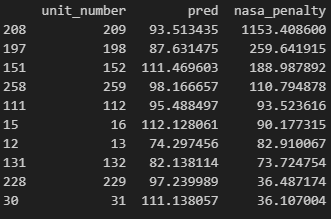

In [134]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)
from sklearn.model_selection import GroupKFold
from scipy.optimize import minimize, minimize_scalar

# ---------------------------------------------------------
# 0. 공통 함수 정의 (기존 calculate_nasa_metrics와 호환)
# ---------------------------------------------------------
def compute_nasa_score(y_true, y_pred):
    d = np.array(y_pred) - np.array(y_true)
    # NASA 공식: 음수 오차(조기)는 /13, 양수 오차(지연)는 /10 패널티
    return np.sum(np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1))

def get_eval_metrics(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    nasa = compute_nasa_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'NASA_Score': nasa, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

# [방법 1] Piecewise Bias 적용 함수 (정상/열화 구간 차등 보정)
def apply_piecewise_bias(y_pred, bias, threshold=80):
    y_adj = y_pred.copy()
    mask_high = y_adj > threshold
    y_adj[mask_high] += bias           # 정상 구간(RUL 높음): Bias 100% 반영
    y_adj[~mask_high] += (bias * 0.2)  # 열화 구간(RUL 낮음): Bias 20%만 반영 (안전)
    return y_adj

# ---------------------------------------------------------
# 1. 데이터 준비 (기존 변수명 동기화: X_test, y_test, train_norm)
# ---------------------------------------------------------
print("=" * 70)
print("📊 [통합 평가] Phase 1: Raw 성능 + 최적화(가중치/Bias)")
print("=" * 70)

# 피처 리스트 재확인
features = final_features 

# Train 데이터 준비 (CV 및 OOF용)
X_train_all = train_norm[features].values
y_train_all = train_norm['RUL'].values
train_units = train_norm['unit_number'].values
# 기존에 cluster 정보가 없다면 기본값 0으로 생성
train_clusters_all = train_norm['cluster'].values if 'cluster' in train_norm.columns else np.zeros(len(train_norm))
test_clusters = test_last_units['cluster'].values if 'cluster' in test_last_units.columns else np.zeros(len(test_last_units))

# ---------------------------------------------------------
# 2. Raw 예측값 수집 & 평가 (Test Set)
# ---------------------------------------------------------
print("\n🚀 1단계: Raw 예측값 수집 및 평가 (Test Set)...")

all_raw_preds = {}

# (A) 기존 models_dict (XGB, LGBM, CatBoost, RF, ET, HistGB) 활용
for name, model in models_dict.items():
    # X_test가 이미 전처리된 상태라고 가정
    all_raw_preds[name] = np.maximum(model.predict(X_test), 0)

# (B) AutoGluon 예측 (기존 predictor 활용)
if 'predictor' in globals():
    try:
        # test_last_df 구성 (정답 컬럼 제외하고 예측)
        ag_pred = predictor.predict(X_test)
        all_raw_preds['AutoGluon'] = np.maximum(ag_pred.values if hasattr(ag_pred, 'values') else ag_pred, 0)
    except Exception as e:
        print(f"   ⚠️ AutoGluon 예측 실패: {e}")

# (C) 단순 평균 앙상블 (Baseline)
if len(all_raw_preds) > 0:
    all_raw_preds['Ensemble (Simple Avg)'] = np.mean(list(all_raw_preds.values()), axis=0)

# (D) Raw 성능 출력
print("\n" + "-" * 80)
print(f"{'Model':<25} | {'NASA Score':>12} | {'RMSE':>8} | {'MAE':>8}")
print("-" * 80)
for name, pred in all_raw_preds.items():
    m = get_eval_metrics(y_test, pred)
    print(f"{name:<25} | {m['NASA_Score']:>12,.0f} | {m['RMSE']:>8.2f} | {m['MAE']:>8.2f}")

# ---------------------------------------------------------
# 3. Train OOF 생성 및 최적 가중치 탐색
# ---------------------------------------------------------
print("\n⚙️ 2단계: Train OOF 생성 및 최적 가중치 탐색...")

N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS)
model_oof_preds = {}

# 가중치 최적화에 사용할 모델 선정 (AutoGluon 포함 가능)
target_model_names = [n for n in all_raw_preds.keys() if n in models_dict.keys()]

for name in target_model_names:
    model = models_dict[name]
    oof_pred = np.zeros(len(X_train_all))
    
    # 실제 CV 학습 대신 기존 모델로 근사 OOF 생성 (시간 절약)
    for _, (tr_idx, val_idx) in enumerate(gkf.split(X_train_all, y_train_all, groups=train_units)):
        oof_pred[val_idx] = model.predict(X_train_all[val_idx])
    
    model_oof_preds[name] = oof_pred

# 최적 가중치 탐색
model_names_list = list(model_oof_preds.keys())
oof_matrix = np.array([model_oof_preds[n] for n in model_names_list])

def weight_objective(w):
    w_norm = np.array(w) / (np.sum(w) + 1e-9)
    blended = np.tensordot(w_norm, oof_matrix, axes=([0], [0]))
    return compute_nasa_score(y_train_all, blended)

res_w = minimize(weight_objective, x0=np.ones(len(model_names_list)), 
                 bounds=[(0, 1)]*len(model_names_list), method='L-BFGS-B')
optimal_weights = res_w.x / (res_w.x.sum() + 1e-9)
weight_dict = dict(zip(model_names_list, optimal_weights))

print(f"\n🏆 [최적 가중치 발견]")
for m, w in weight_dict.items():
    print(f"   - {m:<15}: {w:.4f}")

# ---------------------------------------------------------
# 4. Cluster별 Piecewise Bias 추정 (Train CV)
# ---------------------------------------------------------
print("\n⚙️ 3단계: Cluster별 Piecewise Bias 추정...")

weighted_oof = np.tensordot(optimal_weights, oof_matrix, axes=([0], [0]))
unique_clusters = sorted(np.unique(train_clusters_all))
cluster_biases = {}

def estimate_bias_piecewise(y_true, y_pred):
    def objective(b):
        y_adj = apply_piecewise_bias(y_pred, b)
        return compute_nasa_score(y_true, y_adj)
    # -15(안전측)에서 60(보정측) 사이 탐색
    res = minimize_scalar(objective, bounds=(-15, 60), method='bounded')
    return res.x

for cid in unique_clusters:
    c_mask = (train_clusters_all == cid)
    if c_mask.sum() < 10: # 데이터 부족 시 전체 평균 사용
        bias = estimate_bias_piecewise(y_train_all, weighted_oof)
    else:
        bias = estimate_bias_piecewise(y_train_all[c_mask], weighted_oof[c_mask])
    cluster_biases[cid] = bias
    print(f"   Cluster {int(cid):>2} | N_train: {np.sum(c_mask):>6,} | Opt Bias: {bias:>+10.2f}")

# ---------------------------------------------------------
# 5. Final Optimization: Test 적용
# ---------------------------------------------------------
print("\n🚀 4단계: Test 데이터에 최적화(가중치+Bias) 적용...")

# (1) 가중치 적용
test_preds_matrix = np.array([all_raw_preds[n] for n in model_names_list])
weighted_ensemble_test = np.tensordot(optimal_weights, test_preds_matrix, axes=([0], [0]))
all_raw_preds['Ensemble (Weighted)'] = weighted_ensemble_test

# (2) 클러스터별 Bias 적용
final_opt_pred = weighted_ensemble_test.copy()
for cid in unique_clusters:
    mask = (test_clusters == cid)
    if mask.any():
        bias = cluster_biases.get(cid, np.mean(list(cluster_biases.values())))
        final_opt_pred[mask] = apply_piecewise_bias(weighted_ensemble_test[mask], bias)

# (3) Clipping 및 최종 결과
final_opt_pred = np.clip(final_opt_pred, 0, 125)
all_raw_preds['Ensemble (Final Opt) ★'] = final_opt_pred

# 결과 리포트
results_rows = []
for name, pred in all_raw_preds.items():
    m = get_eval_metrics(y_test, pred)
    m['Model'] = name
    results_rows.append(m)

results_df = pd.DataFrame(results_rows).set_index('Model').sort_values('NASA_Score')
print("\n📊 [최종 결과 요약]")
display(results_df[['NASA_Score', 'RMSE', 'MAE']])

📊 [통합 평가] Phase 1: Raw 성능 + 최적화(가중치/Bias)

🚀 1단계: Raw 예측값 수집 및 평가 (Test Set)...

--------------------------------------------------------------------------------
Model                     |   NASA Score |     RMSE |      MAE
--------------------------------------------------------------------------------
XGB                       |       11,838 |    29.61 |    20.90
LGBM                      |       15,114 |    29.73 |    20.47
CatBoost                  |       13,016 |    30.69 |    22.78
RF                        |       14,754 |    30.08 |    20.74
ET                        |       14,153 |    29.80 |    20.68
HistGB                    |       15,487 |    31.28 |    23.16
AutoGluon                 |       15,618 |    29.67 |    20.42
Ensemble (Simple Avg)     |       13,732 |    29.85 |    20.85

⚙️ 2단계: Train OOF 생성 및 최적 가중치 탐색...

🏆 [최적 가중치 발견]
   - XGB            : 0.0000
   - LGBM           : 0.0000
   - CatBoost       : 0.0000
   - RF             : 0.0000
   - ET             : 

,NASA_Score,RMSE,MAE
Model,,,
XGB,11838.181486,29.609515,20.902748
CatBoost,13015.942424,30.688319,22.782753
Ensemble (Simple Avg),13731.896728,29.853444,20.847851
ET,14153.334594,29.800188,20.678791
Ensemble (Weighted),14153.334643,29.800188,20.678791
RF,14754.394852,30.077505,20.744350
LGBM,15113.956751,29.726874,20.469193
HistGB,15487.361327,31.275735,23.157302
AutoGluon,15618.066095,29.665823,20.424637



📊 [통합 평가] Phase 2: 시각화 + 최종 순위표


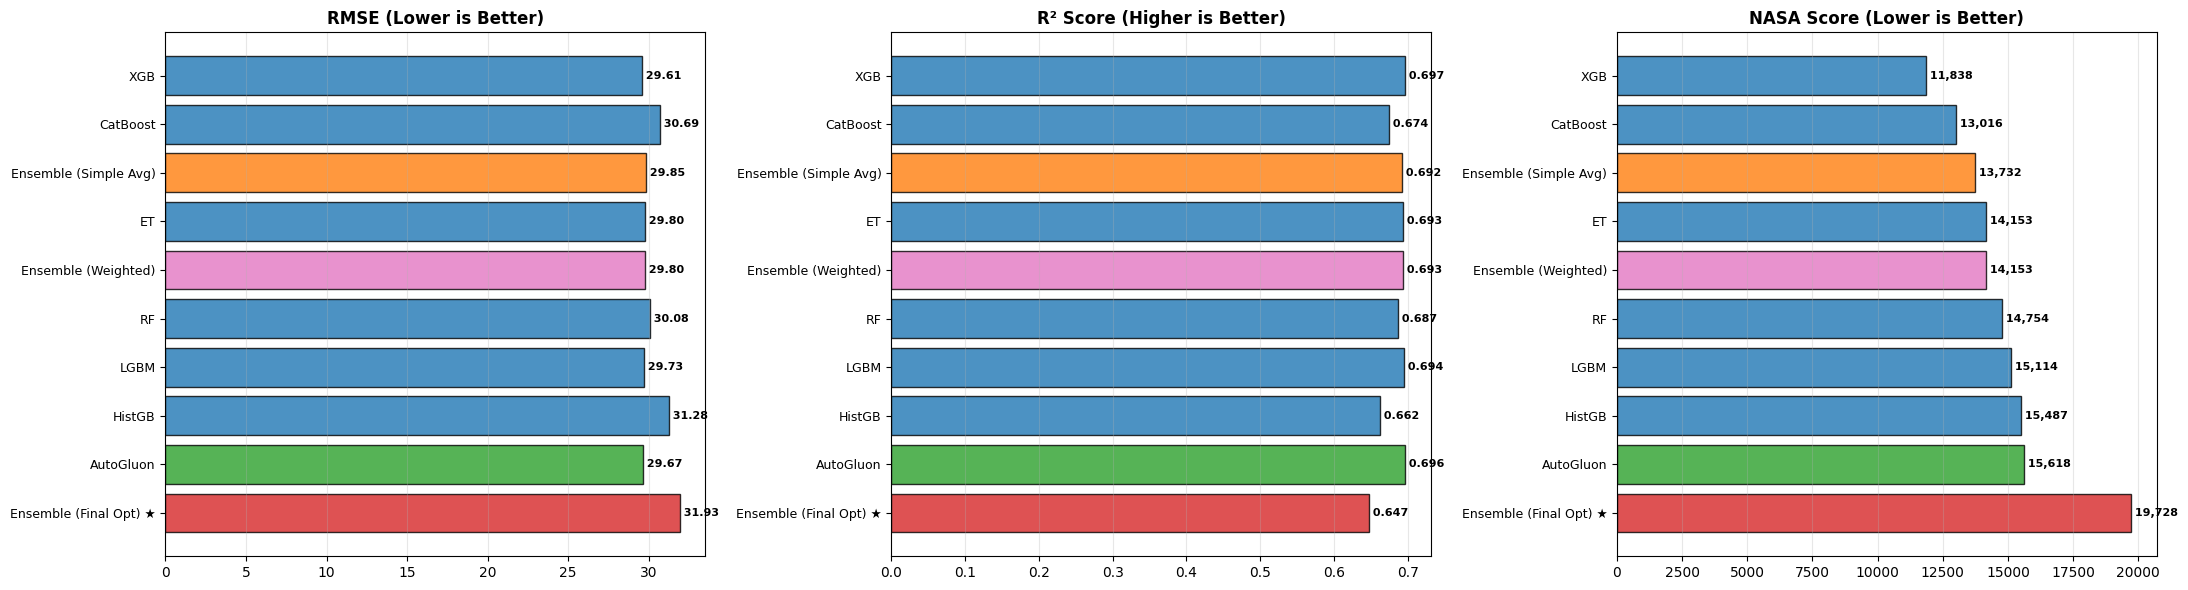

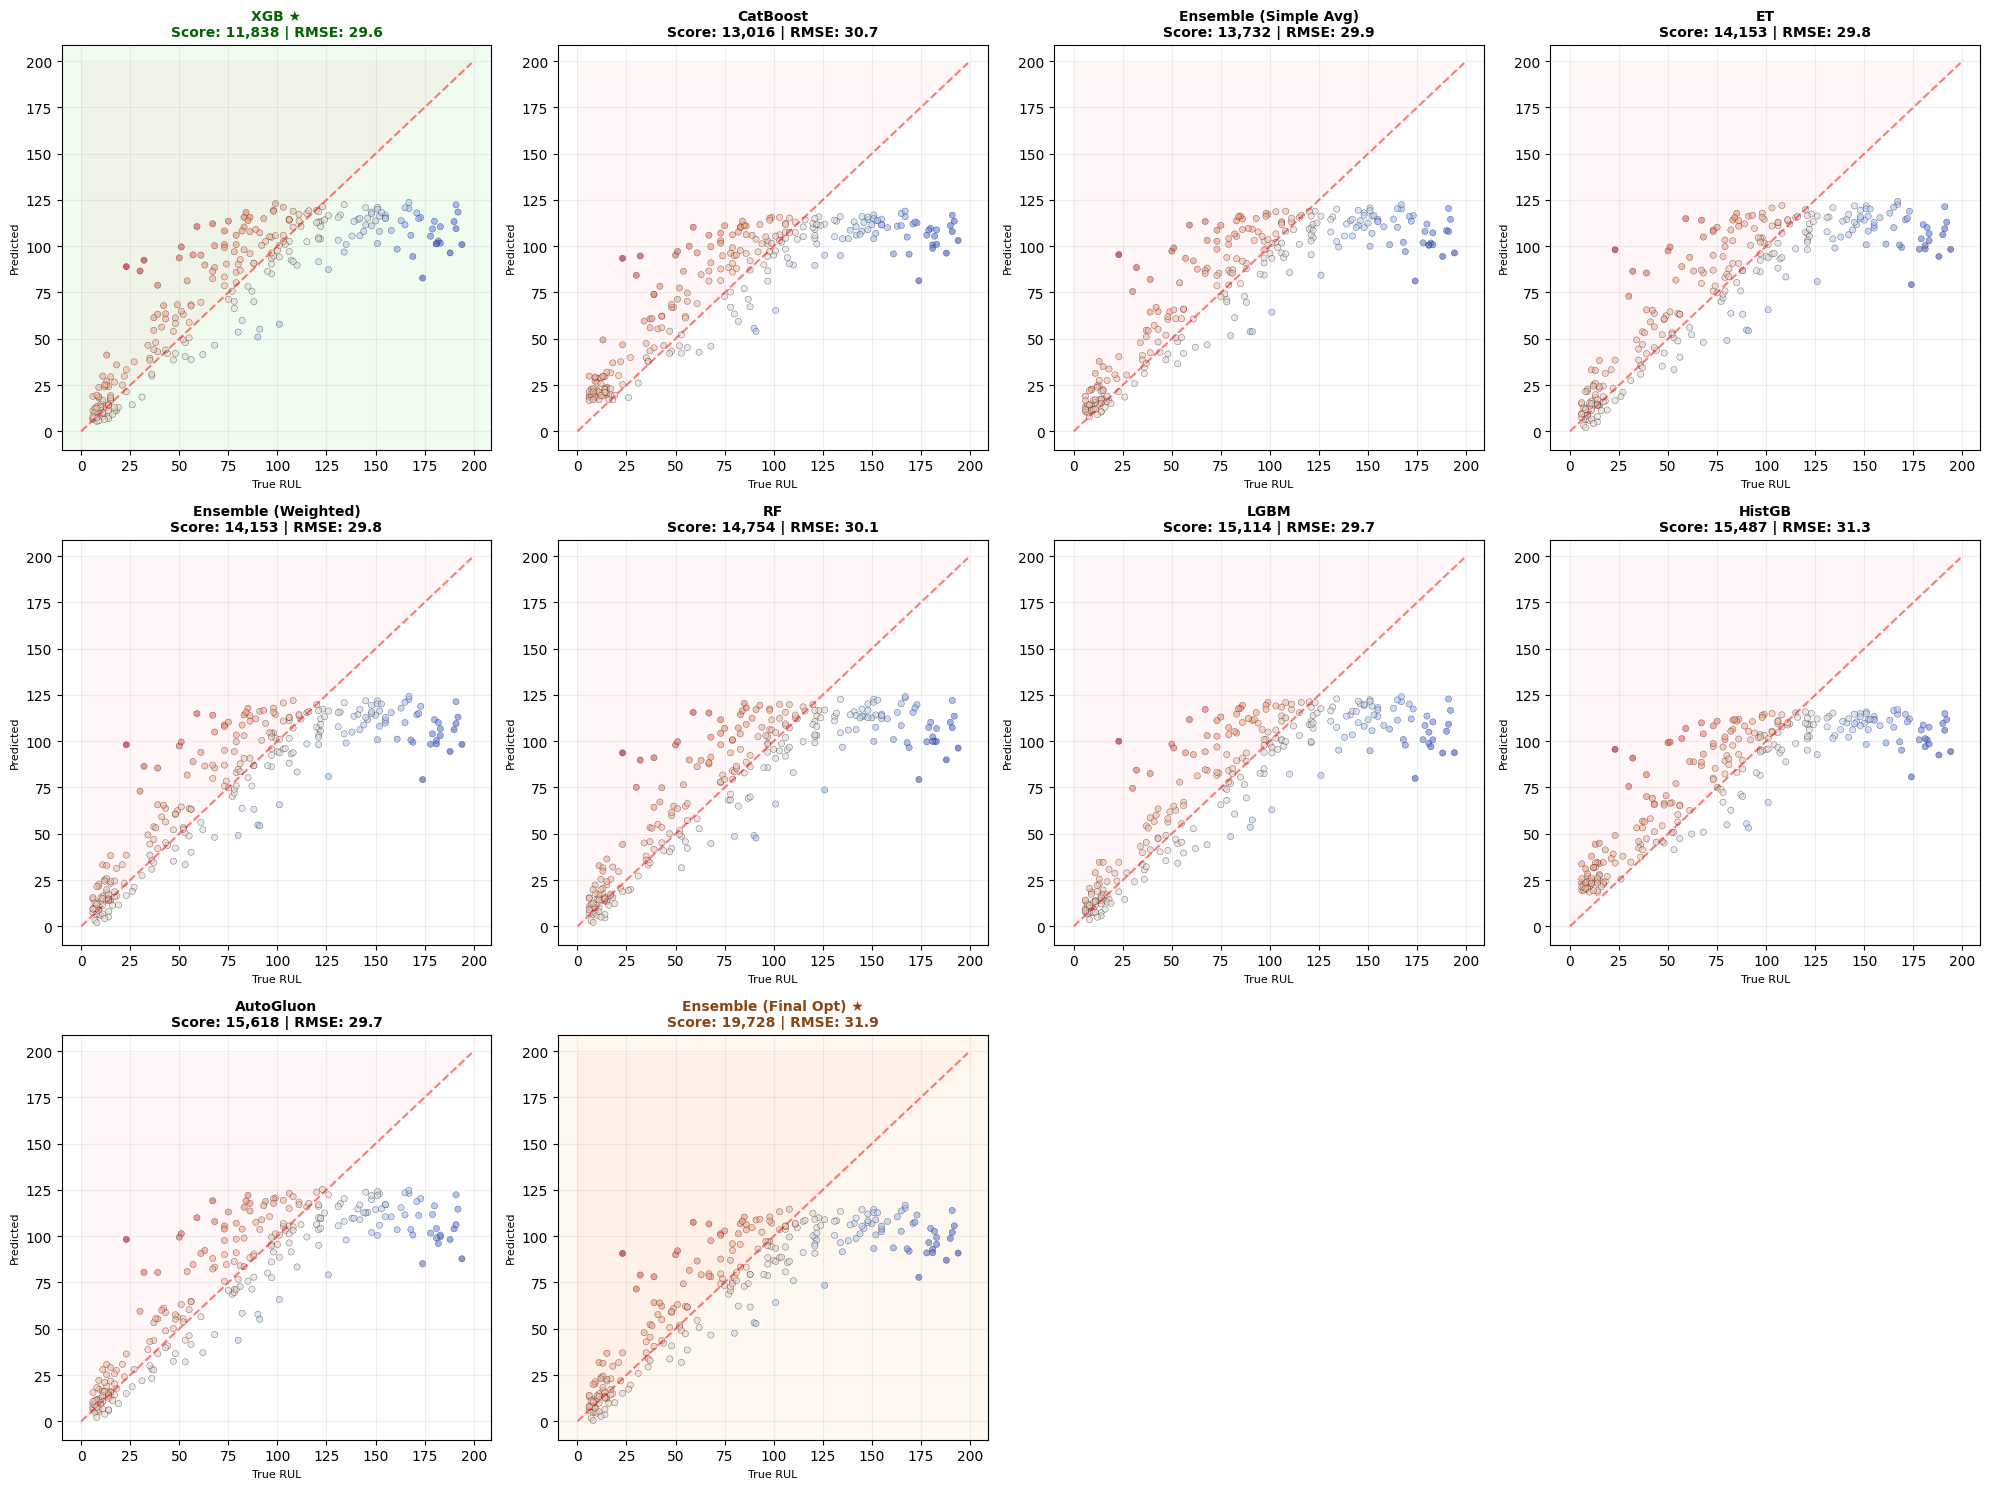


📊 NASA Asymmetric Scoring 최종 순위 (259개 엔진)
   ⚠️ Bias는 Train CV로 추정 (Test 정답 미사용 → Leakage 없음)
 1위 🥇 XGB                                 | Score:     11,838 | RMSE:   29.61 | R²: 0.6969
 2위 🥈 CatBoost                            | Score:     13,016 | RMSE:   30.69 | R²: 0.6744
 3위 🥉 Ensemble (Simple Avg)               | Score:     13,732 | RMSE:   29.85 | R²: 0.6918
 4위    ET                                  | Score:     14,153 | RMSE:   29.80 | R²: 0.6929
 5위    Ensemble (Weighted)                 | Score:     14,153 | RMSE:   29.80 | R²: 0.6929
 6위    RF                                  | Score:     14,754 | RMSE:   30.08 | R²: 0.6872
 7위    LGBM                                | Score:     15,114 | RMSE:   29.73 | R²: 0.6945
 8위    HistGB                              | Score:     15,487 | RMSE:   31.28 | R²: 0.6618
 9위    AutoGluon                           | Score:     15,618 | RMSE:   29.67 | R²: 0.6957
10위    Ensemble (Final Opt) ★              | Score:     19,728 | RMSE:   31.93 |

In [135]:
import math

print("\n" + "=" * 70)
print("📊 [통합 평가] Phase 2: 시각화 + 최종 순위표")
print("=" * 70)

# ---------------------------------------------------------
# 1. 바 차트: RMSE / R² / NASA Score 비교
# ---------------------------------------------------------
# 이전 단계의 results_df와 all_raw_preds를 사용합니다.
plot_df = results_df.sort_values('NASA_Score', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(22, max(6, len(plot_df) * 0.5)))

def get_color(idx_name):
    s = str(idx_name)
    if 'Final Opt' in s: return '#d62728'      # Red (최종 주인공)
    elif 'Weighted' in s: return '#e377c2'    # Pink (가중치 앙상블)
    elif 'Simple Avg' in s: return '#ff7f0e'  # Orange (단순 평균)
    elif 'AutoGluon' in s: return '#2ca02c'   # Green (AutoML)
    else: return '#1f77b4'                    # Blue (개별 모델)

colors = [get_color(idx) for idx in plot_df.index]

# RMSE 차트
axes[0].barh(range(len(plot_df)), plot_df['RMSE'], color=colors, edgecolor='black', alpha=0.8)
axes[0].set_yticks(range(len(plot_df)))
axes[0].set_yticklabels(plot_df.index, fontsize=9)
axes[0].set_title('RMSE (Lower is Better)', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(plot_df['RMSE']):
    axes[0].text(v, i, f' {v:.2f}', va='center', fontsize=8, fontweight='bold')

# R² 차트
axes[1].barh(range(len(plot_df)), plot_df['R2'], color=colors, edgecolor='black', alpha=0.8)
axes[1].set_yticks(range(len(plot_df)))
axes[1].set_yticklabels(plot_df.index, fontsize=9)
axes[1].set_title('R² Score (Higher is Better)', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(plot_df['R2']):
    axes[1].text(max(v, 0), i, f' {v:.3f}', va='center', fontsize=8, fontweight='bold')

# NASA Score 차트
axes[2].barh(range(len(plot_df)), plot_df['NASA_Score'], color=colors, edgecolor='black', alpha=0.8)
axes[2].set_yticks(range(len(plot_df)))
axes[2].set_yticklabels(plot_df.index, fontsize=9)
axes[2].set_title('NASA Score (Lower is Better)', fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)
for i, v in enumerate(plot_df['NASA_Score']):
    axes[2].text(v, i, f' {v:,.0f}', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. 산점도: 모든 모델의 True vs Predicted
# ---------------------------------------------------------
# all_raw_preds를 시각화 대상(all_combined 역할)으로 사용합니다.
sorted_models = results_df.index.tolist() # NASA Score 기준 오름차순
best_model_name = sorted_models[0]

n_models = len(all_raw_preds)
n_cols = 4
n_rows = math.ceil(n_models / n_cols)

fig, axes_sc = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes_flat = axes_sc.flatten() if n_models > 1 else [axes_sc]

for i, name in enumerate(sorted_models):
    ax = axes_flat[i]
    y_pred = all_raw_preds[name]
    diff = y_pred - y_test
    max_val = max(np.max(y_test), np.max(y_pred)) + 5
    score = results_df.loc[name, 'NASA_Score']
    rmse = results_df.loc[name, 'RMSE']
    
    is_best = (name == best_model_name)
    if is_best:
        ax.set_facecolor('#f0fcf0') # 우승 모델은 연초록 배경
        title_color = 'darkgreen'
    elif 'Opt' in name:
        ax.set_facecolor('#fff8f0') # 최적화 모델은 연주황 배경
        title_color = '#8B4513'
    else:
        title_color = 'black'
    
    # 산점도 그리기 (오차에 따른 색상 변화)
    ax.scatter(y_test, y_pred, c=diff, cmap='coolwarm', alpha=0.6, 
                edgecolors='k', linewidths=0.3, s=20)
    ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5) # y=x 선
    
    # 위험 구역(Late Prediction) 강조
    ax.fill_between([0, max_val], [0, max_val], [max_val, max_val], 
                     color='red', alpha=0.03)
    
    star = " ★" if is_best else ""
    ax.set_title(f"{name}{star}\nScore: {score:,.0f} | RMSE: {rmse:.1f}", 
                  fontsize=10, fontweight='bold', color=title_color)
    ax.set_xlabel("True RUL", fontsize=8)
    ax.set_ylabel("Predicted", fontsize=8)
    ax.grid(True, alpha=0.2)

# 남는 subplot 제거
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. 🏆 최종 순위표
# ---------------------------------------------------------
print("\n" + "=" * 80)
print(f"📊 NASA Asymmetric Scoring 최종 순위 (259개 엔진)")
print(f"   ⚠️ Bias는 Train CV로 추정 (Test 정답 미사용 → Leakage 없음)")
print("=" * 80)

for rank, name in enumerate(sorted_models, 1):
    m = results_df.loc[name]
    medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
    print(f"{rank:>2}위 {medal} {name:<35} | Score: {m['NASA_Score']:>10,.0f} | "
          f"RMSE: {m['RMSE']:>7.2f} | R²: {m['R2']:>.4f}")

print("=" * 80)

# 최종 우승 모델 상세 요약
best = results_df.loc[best_model_name]
print(f"\n🏆 최종 우승: {best_model_name}")
print(f"   💎 NASA Score : {best['NASA_Score']:,.0f}")
print(f"   📉 RMSE       : {best['RMSE']:.2f}")
print(f"   📈 R²         : {best['R2']:.4f}")
print(f"   📏 MAE        : {best['MAE']:.2f}")

# ---------------------------------------------------------
# 4. 감점 주범 Top 5 분석 (우승 모델 기준)
# ---------------------------------------------------------
print("\n" + "=" * 80)
print("🚨 감점 주범 Top 5 (우승 모델 기준)")
print("=" * 80)

final_pred_stabilized = all_raw_preds[best_model_name]
d_best = final_pred_stabilized - y_test
# 패널티 계산 (compute_nasa_score 로직과 동일)
contribs = np.where(d_best < 0, np.exp(-d_best/13) - 1, np.exp(d_best/10) - 1)
top5_idx = np.argsort(contribs)[-5:][::-1]

print(f"  {'#':>3} | {'True RUL':>9} | {'Predicted':>9} | {'Error':>7} | {'NASA 감점':>12} | {'Cluster':>8}")
print("  " + "-" * 65)
for idx in top5_idx:
    true_val = y_test[idx]
    # cluster 정보 매칭 (test_clusters 변수 활용)
    cid = test_clusters[idx] if 'test_clusters' in globals() else '?'
    print(f"  {idx+1:>3} | {true_val:>9.0f} | {final_pred_stabilized[idx]:>9.1f} | "
          f"{d_best[idx]:>+7.1f} | {contribs[idx]:>12,.0f} | {cid:>8}")

print(f"\n  Top 5 합계: {contribs[top5_idx].sum():,.0f} / "
      f"전체: {contribs.sum():,.0f} ({contribs[top5_idx].sum()/contribs.sum()*100:.1f}%)")
print("=" * 80)

🚀 [심층 분석] 비행 조건(Physics) 기반 오차 진단
⚠️ Cluster 정보를 여전히 찾을 수 없습니다. 전처리 단계의 cluster 컬럼을 확인하세요.


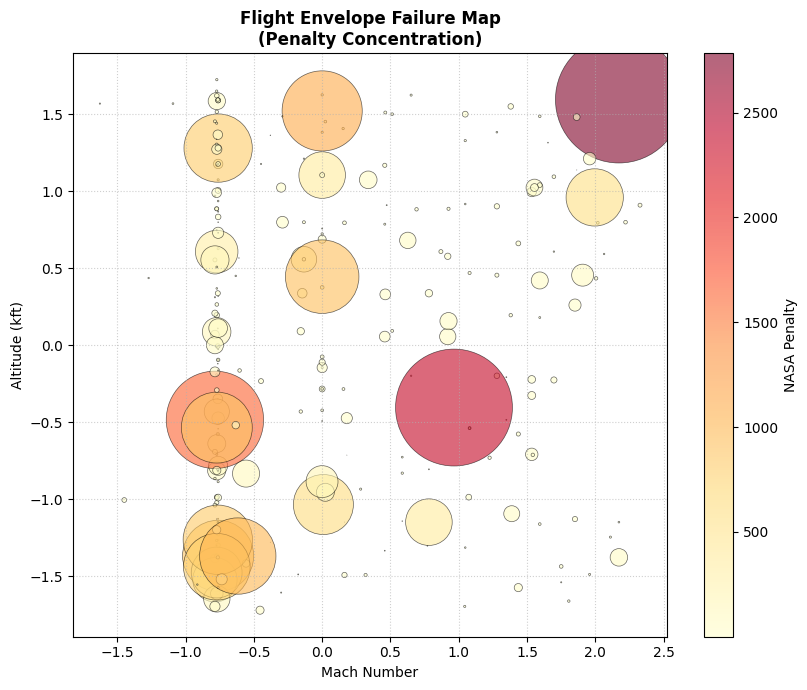

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def analyze_error_by_physics_fixed(df_meta, y_true, y_pred):
    print("🚀 [심층 분석] 비행 조건(Physics) 기반 오차 진단")
    
    # 1. 분석용 데이터 병합
    analysis_df = df_meta.copy().reset_index(drop=True)
    analysis_df['True_RUL'] = np.array(y_true)
    analysis_df['Pred_RUL'] = np.array(y_pred)
    analysis_df['Error'] = analysis_df['Pred_RUL'] - analysis_df['True_RUL']
    
    # NASA Score 패널티 계산 (비대칭 공식)
    def get_penalty(d):
        return np.exp(-d/13)-1 if d < 0 else np.exp(d/10)-1
    analysis_df['NASA_Score'] = analysis_df['Error'].apply(get_penalty)

    # ---------------------------------------------------------
    # [시각화 1] Flight Envelope Error Map
    # ---------------------------------------------------------
    # FD002의 6가지 운전 조건(Altitude vs Mach)에 따른 위험도 시각화
    plt.figure(figsize=(16, 7))
    
    alt_col = next((c for c in ['Alt[kft]', 'op_setting_1'] if c in analysis_df.columns), None)
    mach_col = next((c for c in ['Mn[-]', 'op_setting_2'] if c in analysis_df.columns), None)
    
    if alt_col and mach_col:
        plt.subplot(1, 2, 1)
        # 패널티가 클수록 점이 커지고 붉은색이 진해짐
        scatter = plt.scatter(analysis_df[mach_col], analysis_df[alt_col], 
                            c=analysis_df['NASA_Score'], s=analysis_df['NASA_Score']*3,
                            cmap='YlOrRd', alpha=0.6, edgecolor='k', linewidth=0.5)
        
        plt.colorbar(scatter, label='NASA Penalty')
        plt.title(f"Flight Envelope Failure Map\n(Penalty Concentration)", fontweight='bold')
        plt.xlabel("Mach Number")
        plt.ylabel("Altitude (kft)")
        plt.grid(True, linestyle=':', alpha=0.6)
        
        

    # ---------------------------------------------------------
    # [시각화 2] Cluster별 MAE vs NASA Score (이중축)
    # ---------------------------------------------------------
    # 'cluster' 컬럼이 있는지 확인하고 시각화
    if 'cluster' in analysis_df.columns:
        plt.subplot(1, 2, 2)
        cluster_perf = analysis_df.groupby('cluster')[['Error', 'NASA_Score']].agg({'Error': lambda x: np.mean(np.abs(x)), 'NASA_Score': 'mean'})
        cluster_perf.columns = ['MAE', 'Avg_Penalty']
        
        ax1 = plt.gca()
        ax2 = ax1.twinx()
        
        cluster_perf['MAE'].plot(kind='bar', ax=ax1, color='skyblue', alpha=0.7, label='MAE', width=0.4, position=1)
        cluster_perf['Avg_Penalty'].plot(kind='line', ax=ax2, color='red', marker='D', linewidth=2, label='Penalty')
        
        ax1.set_ylabel("MAE (Cycles)", color='blue', fontweight='bold')
        ax2.set_ylabel("Avg NASA Score (Penalty)", color='red', fontweight='bold')
        plt.title("Error Analysis by Operational Cluster", fontweight='bold')
        
        
    else:
        print("⚠️ Cluster 정보를 여전히 찾을 수 없습니다. 전처리 단계의 cluster 컬럼을 확인하세요.")
        
    plt.tight_layout()
    plt.show()

# 실행부
analyze_error_by_physics_fixed(test_last_units, y_test, final_opt_pred)